<a href="https://colab.research.google.com/github/Crustaly/cis2450project/blob/main/london_airbnb_completed.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Airbnb Pricing & Geographic Factors - London

**Research Question:** What geographic and neighborhood factors, including proximity to restaurants, cafes, bars, tourist attractions, parks, and transit, are most associated with Airbnb pricing in London?

**Data Sources**
- `airbnb_listings.csv` - Inside Airbnb listings exported to CSV
- `london_osm.geojson` - OpenStreetMap POI data exported from Overpass Turbo

**Main Outputs**
- Cleaned modeling table with Airbnb listing features joined to spatial OSM features
- EDA visuals and statistical summaries
- Baseline linear regression, tuned ridge regression with interaction terms, and tuned random forest regression
- Exported artifacts for an interactive Streamlit dashboard

---

## 0. Environment Setup

In [6]:
# install the geo, dashboard, and other things
!pip install -q geopandas shapely pyproj rtree plotly folium streamlit joblib duckdb polars

In [7]:
import warnings
warnings.filterwarnings('ignore')

import json
import os
from pathlib import Path

import numpy as np
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import plotly.express as px
import duckdb
import polars as pl
import joblib

from shapely.geometry import Point, shape

from scipy.stats import loguniform, ttest_ind

from sklearn.model_selection import train_test_split, RandomizedSearchCV, KFold
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder, PolynomialFeatures
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.ensemble import RandomForestRegressor
from sklearn.inspection import permutation_importance
from sklearn.metrics import mean_squared_error, mean_absolute_error, median_absolute_error, r2_score

pd.set_option('display.max_columns', 80)
pd.set_option('display.float_format', '{:.4f}'.format)
plt.rcParams['figure.figsize'] = (10, 5)
plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.spines.right'] = False

RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)


# these are the colab file paths i used.
# if running locally, put the data files next to the notebook or update these paths.
AIRBNB_PATH = '/content/airbnb_listings.csv'
OSM_PATH = '/content/london_osm.geojson' #changed pls when u upload file be careful!
OUTPUT_DIR = Path('/content/airbnb_project_outputs')
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

print('environment ready.')

environment ready.


---
## 1. Load Data

In [8]:
# load up the airbnb csv data, can u fix the data its loading wrong
df_raw = pd.read_csv(AIRBNB_PATH, low_memory=False)

print(f'shape   : {df_raw.shape}')
print(f'columns : {list(df_raw.columns)}')
df_raw.head(3)

shape   : (152563, 20)
columns : ['id', 'name', 'host_id', 'host_name', 'neighbourhood_group', 'neighbourhood', 'latitude', 'longitude', 'room_type', 'price', 'minimum_nights', 'number_of_reviews', 'last_review', 'reviews_per_month', 'calculated_host_listings_count', 'availability_365', 'number_of_reviews_ltm', 'license', 'city', 'scrape_date']


,id,name,host_id,host_name,neighbourhood_group,neighbourhood,latitude,longitude,room_type,price,minimum_nights,number_of_reviews,last_review,reviews_per_month,calculated_host_listings_count,availability_365,number_of_reviews_ltm,license,city,scrape_date
0,13913,Holiday London DB Room Let-on going,54730,Alina,NaN,Islington,51.5686,-0.1127,Private room,70.0000,1,55,2025-08-21,0.3000,2,331,10,NaN,London,2026-03-29
1,15400,Bright Chelsea Apartment. Chelsea!,60302,Philippa,NaN,Kensington and Chelsea,51.4878,-0.1681,Entire home/apt,149.0000,4,97,2025-04-05,0.5100,1,199,1,NaN,London,2026-03-29
2,17402,Very Central Modern 3-Bed/2 Bath By Oxford St W1,67564,Liz,NaN,Westminster,51.5219,-0.1409,Entire home/apt,411.0000,3,56,2024-02-19,0.3200,2,80,0,NaN,London,2026-03-29


In [9]:
import os

print('Listing all airbnb_listings.csv files and their sizes:')

found_files = []
for root, dirs, files in os.walk('/content'):
    for file in files:
        if 'airbnb_listings.csv' in file:
            full_path = os.path.join(root, file)
            size_bytes = os.path.getsize(full_path)
            size_mb = size_bytes / (1024 * 1024)
            found_files.append({'path': full_path, 'size_mb': f'{size_mb:.2f}'})

if found_files:
    for f in found_files:
        print(f"  - {f['path']} ({f['size_mb']} MB)")
else:
    print('No airbnb_listings.csv files found.')

Listing all airbnb_listings.csv files and their sizes:
  - /content/airbnb_listings.csv (27.00 MB)


If a larger file is found, you can update the `AIRBNB_PATH` variable in the `cell-imports` cell to point to the correct file path. For example:

```python
AIRBNB_PATH = '/path/to/your/larger/airbnb_listings.csv'
```

After updating, re-run the `cell-imports` and `cell-load-airbnb` cells to load the larger dataset.

In [10]:
# check both files before doing heavier work -> ok works!
# the main join later connects airbnb listings with openstreetmap poi data, not here
required_files = {
    'Airbnb listings CSV': AIRBNB_PATH,
    'London OSM GeoJSON': OSM_PATH,
}

missing_files = [label for label, path in required_files.items() if not Path(path).exists()]

if missing_files:
    print('Missing required files:')
    for label in missing_files:
        print(f'  - {label}: {required_files[label]}')
    print('\nUpload the files to Colab or update AIRBNB_PATH and OSM_PATH before running the next cells.')
else:
    print('Both source files are present.')

Both source files are present.


In [11]:
# loading the osm geojson safely (skipping any weird geometries)
import json
import geopandas as gpd
from shapely.geometry import shape

with open(OSM_PATH, "r", encoding="utf-8") as f:
    osm_json = json.load(f)

features = osm_json["features"]
print("total raw features:", len(features))

good_rows = []
bad_count = 0

for feat in features:
    geom = feat.get("geometry")
    props = feat.get("properties", {})

    if geom is None:
        bad_count += 1
        continue

    try:
        shp = shape(geom)

        if shp.is_empty:
            bad_count += 1
            continue

        row = props.copy()
        row["geometry"] = shp
        good_rows.append(row)

    except Exception:
        bad_count += 1
        continue

print("valid features kept:", len(good_rows))
print("invalid features dropped:", bad_count)

gdf_osm_raw = gpd.GeoDataFrame(good_rows, geometry="geometry", crs="EPSG:4326")

print(f'shape          : {gdf_osm_raw.shape}')
print(f'crs            : {gdf_osm_raw.crs}')
print(f'geometry types : {gdf_osm_raw.geometry.geom_type.value_counts().to_dict()}')
print(f'columns        : {list(gdf_osm_raw.columns)}')

gdf_osm_raw.head(3)

total raw features: 60884
valid features kept: 60882
invalid features dropped: 2
shape          : (60882, 1239)
crs            : EPSG:4326
geometry types : {'Point': 60880, 'LineString': 2}
columns        : ['@id', 'cycleway:left', 'cycleway:right', 'cycleway:right:oneway', 'highway', 'lanes', 'lit', 'maxspeed', 'name', 'public_transport', 'ref:GB:usrn', 'sidewalk:left', 'sidewalk:right', 'surface', '@tainted', 'geometry', 'access', 'bus', 'covered', 'departures_board', 'motor_vehicle', 'oneway', 'operator', 'addr:city', 'building', 'building:levels', 'castle_type', 'heritage', 'heritage:operator', 'heritage:website', 'historic', 'listed_status', 'ref:GB:nhle', 'tourism', 'type', 'wheelchair', 'wikidata', 'wikimedia_commons', 'wikipedia', '@geometry', 'addr:postcode', 'addr:street', 'air_conditioning', 'alt_name', 'contact:facebook', 'contact:instagram', 'contact:twitter', 'email', 'end_date', 'fee', 'inscription_date', 'internet_access', 'museum', 'name:en', 'name:es', 'name:ja', 'nam

,@id,cycleway:left,cycleway:right,cycleway:right:oneway,highway,lanes,lit,maxspeed,name,public_transport,ref:GB:usrn,sidewalk:left,sidewalk:right,surface,@tainted,geometry,access,bus,covered,departures_board,motor_vehicle,oneway,operator,addr:city,building,building:levels,castle_type,heritage,heritage:operator,heritage:website,historic,listed_status,ref:GB:nhle,tourism,type,wheelchair,wikidata,wikimedia_commons,wikipedia,@geometry,...,payment:card,construction:name,diet:kosher:certification,diet:kosher:glatt,diet:kosher:expires,diet:kosher:certification-expires,name:bu,check_date:opening_hours:url,was:brewery,name:official,parking:both,parking:both:restriction:reason,was:contact:instagram,payment:mastercard_contactless,payment:online_payment,ref:landlord,drink:espresso,drink:filter_coffee,payment:nfc_mobile_payments,source:amenity,contact:mastodon,drinking_water,fee:drinking_water,wikidata:operator,repeat_on,fhrs:local_authority,diet:non-halal,sells,shuffleboard,diet:kosher:meaty,language:sgn-GB,note:takeaway,billiards:fee,darts,darts:fee,darts:type,table_tennis,serving_system:buffet,name:zh-Latn-pinyin,drink:craft_beer
0,way/10698806,no,separate,no,tertiary,2,yes,20 mph,Battery Road,stop_position,20800128,yes,separate,asphalt,True,"LINESTRING (0.08897 51.49847, 0.08887 51.49832)",NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,way/656712860,NaN,NaN,NaN,service,NaN,yes,NaN,NaN,platform,NaN,NaN,NaN,asphalt,True,"LINESTRING (-0.32639 51.48713, -0.32628 51.48728)",no,yes,yes,timetable,permissive,yes,Sky UK,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,relation/21104,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Hampton Court Palace,NaN,NaN,NaN,NaN,NaN,NaN,POINT (-0.33774 51.40366),NaN,NaN,NaN,NaN,NaN,NaN,NaN,London,palace,3,palace,2,Historic England,https://historicengland.org.uk/listing/the-lis...,castle,Grade I,1193127,attraction,multipolygon,limited,Q205666,Category:Hampton Court Palace,en:Hampton Court Palace,center,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [12]:
# convert osm shapes into representative points so every poi works in the same distance logic.
# did this b/c representative points help with polygon pois like parks because they stay inside the original shape
gdf_osm_raw['geometry'] = gdf_osm_raw.geometry.representative_point()

print(gdf_osm_raw.geometry.geom_type.value_counts())
gdf_osm_raw.head(3)

Point    60882
Name: count, dtype: int64


,@id,cycleway:left,cycleway:right,cycleway:right:oneway,highway,lanes,lit,maxspeed,name,public_transport,ref:GB:usrn,sidewalk:left,sidewalk:right,surface,@tainted,geometry,access,bus,covered,departures_board,motor_vehicle,oneway,operator,addr:city,building,building:levels,castle_type,heritage,heritage:operator,heritage:website,historic,listed_status,ref:GB:nhle,tourism,type,wheelchair,wikidata,wikimedia_commons,wikipedia,@geometry,...,payment:card,construction:name,diet:kosher:certification,diet:kosher:glatt,diet:kosher:expires,diet:kosher:certification-expires,name:bu,check_date:opening_hours:url,was:brewery,name:official,parking:both,parking:both:restriction:reason,was:contact:instagram,payment:mastercard_contactless,payment:online_payment,ref:landlord,drink:espresso,drink:filter_coffee,payment:nfc_mobile_payments,source:amenity,contact:mastodon,drinking_water,fee:drinking_water,wikidata:operator,repeat_on,fhrs:local_authority,diet:non-halal,sells,shuffleboard,diet:kosher:meaty,language:sgn-GB,note:takeaway,billiards:fee,darts,darts:fee,darts:type,table_tennis,serving_system:buffet,name:zh-Latn-pinyin,drink:craft_beer
0,way/10698806,no,separate,no,tertiary,2,yes,20 mph,Battery Road,stop_position,20800128,yes,separate,asphalt,True,POINT (0.08897 51.49847),NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,way/656712860,NaN,NaN,NaN,service,NaN,yes,NaN,NaN,platform,NaN,NaN,NaN,asphalt,True,POINT (-0.32628 51.48728),no,yes,yes,timetable,permissive,yes,Sky UK,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,relation/21104,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Hampton Court Palace,NaN,NaN,NaN,NaN,NaN,NaN,POINT (-0.33774 51.40366),NaN,NaN,NaN,NaN,NaN,NaN,NaN,London,palace,3,palace,2,Historic England,https://historicengland.org.uk/listing/the-lis...,castle,Grade I,1193127,attraction,multipolygon,limited,Q205666,Category:Hampton Court Palace,en:Hampton Court Palace,center,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


## 2. Clean Airbnb Listings

The raw Airbnb file contains many columns, but obvoisly not all of them are useful for this project. The cleaning step keeps variables that support the main goal: predicting London Airbnb nightly price using listing characteristics and location-based features.

| Issue | Handling | Reason |
|:---|:---|:---|
| Airbnb file may include listings outside London | Filter to London using city labels, borough labels if available, or a London coordinate bounding box | The OSM data covers London, so the Airbnb records must describe the same geographic area. |
| Columns that are 100% missing, such as `license` or `neighbourhood_group` if empty | Drop them before modeling and data-quality summaries | Fully missing columns provide no predictive information and make the retained dataset look less clean. |
| Price may be stored as text or numeric | Strip currency symbols and commas, then convert to numeric | Models require numeric price values. |
| Missing price, latitude, or longitude | Drop these rows | Price is the target variable, and coordinates are required for spatial joins. These cannot be reliably imputed. |
| Non-positive prices | Remove them | A nightly price of zero or below is not meaningful for this prediction task. |
| Extremely large prices | Cap the modeling sample at £5,000 per night | Very high prices are likely rare luxury listings or possible data errors. Keeping them can distort model training, while £5,000 is still high enough to preserve expensive but plausible listings. |
| Right-skewed price distribution | Create `log_price = log(1 + price)` and use it as the modeling target | Airbnb prices are highly skewed. Predicting log-price reduces the influence of extreme listings and makes model errors more stable. |
| Missing `reviews_per_month` | Fill using the median inside the modeling pipeline | Missing review frequency usually means limited or no review activity. Median imputation keeps the row while avoiding leakage from the test set. |
| Other numeric/categorical missing values | Handle inside the scikit-learn preprocessing pipeline | Imputation after the train-test split avoids using test-set information during training. |


In [13]:
# clean the airbnb listings and keep the columns that actually help with eda, mapping, and modeling.


LONDON_BOROUGHS = {
    'barking and dagenham', 'barnet', 'bexley', 'brent', 'bromley', 'camden',
    'city of london', 'croydon', 'ealing', 'enfield', 'greenwich', 'hackney',
    'hammersmith and fulham', 'haringey', 'harrow', 'havering', 'hillingdon',
    'hounslow', 'islington', 'kensington and chelsea', 'kingston upon thames',
    'lambeth', 'lewisham', 'merton', 'newham', 'redbridge',
    'richmond upon thames', 'southwark', 'sutton', 'tower hamlets',
    'waltham forest', 'wandsworth', 'westminster'
}

# bounding box used only as a fallback if city or borough labels are missing.
LONDON_LAT_MIN, LONDON_LAT_MAX = 51.25, 51.75
LONDON_LON_MIN, LONDON_LON_MAX = -0.55, 0.35


def clean_price(series):
    '''Coerce a price column to numeric even if it contains currency symbols or commas.'''
    return pd.to_numeric(
        series.astype(str)
        .str.replace(r'[$£€,]', '', regex=True)
        .str.strip(),
        errors='coerce'
    )


df = df_raw.copy()

# build london mask from whatever location fields are available.
city_mask = pd.Series(False, index=df.index)
borough_mask = pd.Series(False, index=df.index)
bbox_mask = pd.Series(False, index=df.index)

if 'city' in df.columns:
    city_mask = df['city'].astype(str).str.strip().str.lower().str.contains('london', na=False)

if 'neighbourhood_group' in df.columns:
    borough_mask = df['neighbourhood_group'].astype(str).str.strip().str.lower().isin(LONDON_BOROUGHS)

if {'latitude', 'longitude'}.issubset(df.columns):
    bbox_mask = (
        df['latitude'].between(LONDON_LAT_MIN, LONDON_LAT_MAX) &
        df['longitude'].between(LONDON_LON_MIN, LONDON_LON_MAX)
    )

london_mask = city_mask | borough_mask | bbox_mask
if london_mask.any():
    df = df[london_mask].copy()
    print(f'listings after london filter: {len(df):,}')
else:
    print('warning: no London labels or London coordinates were detected, so all rows are kept.')

# conv price and drop rows missing the core fields required for modeling.
if 'price' not in df.columns:
    raise ValueError('The Airbnb dataset must contain a price column.')

df['price'] = clean_price(df['price'])

required = ['price', 'latitude', 'longitude']
before = len(df)
df = df.dropna(subset=[c for c in required if c in df.columns]).copy()
print(f'dropped {before - len(df):,} rows missing price / lat / lon')

# look at invalid and extreme prices.  cap removes listings that are not useful for a night price model.
before = len(df)
df = df[df['price'] > 0].copy()
print(f'dropped {before - len(df):,} rows with non-positive price')

PRICE_CAP = 5000
before = len(df)
df = df[df['price'] <= PRICE_CAP].copy()
print(f'dropped {before - len(df):,} rows with price > {PRICE_CAP}')

# log transform target to reduce right skew!
df['log_price'] = np.log1p(df['price'])

#  only fields that are interpretable and useful for the project.
DESIRED_COLS = [
    'id', 'name', 'city', 'latitude', 'longitude',
    'neighbourhood_group', 'neighbourhood', 'room_type',
    'price', 'log_price', 'minimum_nights', 'number_of_reviews',
    'last_review', 'reviews_per_month', 'calculated_host_listings_count',
    'availability_365', 'number_of_reviews_ltm', 'license', 'scrape_date',
]
KEEP = [c for c in DESIRED_COLS if c in df.columns]
df = df[KEEP].copy()


# common numeric columns are numeric.
for col in ['minimum_nights', 'number_of_reviews', 'calculated_host_listings_count', 'availability_365', 'number_of_reviews_ltm']:
    if col in df.columns:
        df[col] = pd.to_numeric(df[col], errors='coerce')

# cleaned categorical labels.
for col in ['neighbourhood_group', 'neighbourhood', 'room_type']:
    if col in df.columns:
        df[col] = df[col].astype(str).str.strip().replace({'nan': np.nan, 'None': np.nan, '': np.nan})

df = df.reset_index(drop=True)

print(f'after cleaning: {len(df):,} listings and {df.shape[1]} columns')
print('\nprice summary:')
print(df['price'].describe().round(2))

if len(df) < 50_000:
    print('\nwarning: fewer than 50,000 rows remain after cleaning. Confirm with your TA that this is acceptable for your data source.')

df.head(3)

listings after london filter: 96,871
dropped 34,908 rows missing price / lat / lon
dropped 0 rows with non-positive price
dropped 105 rows with price > 5000
after cleaning: 61,858 listings and 19 columns

price summary:
count   61858.0000
mean      189.7500
std       236.2200
min         7.0000
25%        77.0000
50%       135.0000
75%       220.0000
max      5000.0000
Name: price, dtype: float64


,id,name,city,latitude,longitude,neighbourhood_group,neighbourhood,room_type,price,log_price,minimum_nights,number_of_reviews,last_review,reviews_per_month,calculated_host_listings_count,availability_365,number_of_reviews_ltm,license,scrape_date
0,13913,Holiday London DB Room Let-on going,London,51.5686,-0.1127,NaN,Islington,Private room,70.0000,4.2627,1,55,2025-08-21,0.3000,2,331,10,NaN,2026-03-29
1,15400,Bright Chelsea Apartment. Chelsea!,London,51.4878,-0.1681,NaN,Kensington and Chelsea,Entire home/apt,149.0000,5.0106,4,97,2025-04-05,0.5100,1,199,1,NaN,2026-03-29
2,17402,Very Central Modern 3-Bed/2 Bath By Oxford St W1,London,51.5219,-0.1409,NaN,Westminster,Entire home/apt,411.0000,6.0210,3,56,2024-02-19,0.3200,2,80,0,NaN,2026-03-29


In [14]:
# heres our summary after cleaning, ** can u double check this pls
missing = (
    df.isna()
    .sum()
    .rename('missing_count')
    .to_frame()
    .assign(missing_pct=lambda d: 100 * d['missing_count'] / len(df))
    .query('missing_count > 0')
    .sort_values('missing_pct', ascending=False)
)

print('remaining missing values:')
display(missing if not missing.empty else pd.DataFrame({'message': ['no remaining missing values in retained columns']}))

print('\nretained data types:')
display(df.dtypes.rename('dtype').to_frame())

remaining missing values:


,missing_count,missing_pct
neighbourhood_group,61858,100.0000
license,61858,100.0000
last_review,13838,22.3706
reviews_per_month,13838,22.3706



retained data types:


,dtype
id,int64
name,object
city,object
latitude,float64
longitude,float64
neighbourhood_group,float64
neighbourhood,object
room_type,object
price,float64
log_price,float64


In [15]:
# Outlier check used to justify the price cap and log-price target.
outlier_summary = pd.DataFrame({
    'metric': ['price_min', 'price_p50', 'price_p90', 'price_p95', 'price_p99', 'price_max'],
    'value': [
        df['price'].min(),
        df['price'].quantile(0.50),
        df['price'].quantile(0.90),
        df['price'].quantile(0.95),
        df['price'].quantile(0.99),
        df['price'].max(),
    ]
})
outlier_summary

,metric,value
0,price_min,7.0000
1,price_p50,135.0000
2,price_p90,357.0000
3,price_p95,500.0000
4,price_p99,1000.0000
5,price_max,5000.0000


In [16]:
# final structure check before building spatial features
print(f'rows after cleaning: {len(df):,}')
print(f'columns retained    : {df.shape[1]}')
print(f'unique room types   : {df["room_type"].nunique(dropna=True) if "room_type" in df.columns else "not available"}')

rows after cleaning: 61,858
columns retained    : 19
unique room types   : 4


In [17]:
# drop fully empty columns before cleaning/modeling because they add noise but no real signal.
# this keeps the data-quality table easier to read btw
all_missing_cols = [c for c in df.columns if df[c].isna().all()]

if all_missing_cols:
    print("Dropping 100% missing columns:")
    print(all_missing_cols)
    df = df.drop(columns=all_missing_cols)
else:
    print("No 100% missing columns found.")

Dropping 100% missing columns:
['neighbourhood_group', 'license']


---
## 3. Clean & Categorize OSM POIs

### 3a. Normalize property columns

In [18]:
# normalize osm tag columns so the same poi rules work across different overpass exports.
# can u manage the missing expected columns so later code does not break lol
gdf = gdf_osm_raw.copy()

OSM_TAG_COLS = [
    'amenity', 'tourism', 'leisure',
    'public_transport', 'highway', 'railway', 'aerialway',
]

for col in OSM_TAG_COLS:
    if col not in gdf.columns:
        gdf[col] = None
    gdf[col] = (
        gdf[col]
        .astype(str)
        .str.lower()
        .str.strip()
        .replace({'none': None, 'nan': None, '': None})
    )

print('normalized osm columns:', [c for c in gdf.columns if c != 'geometry'])

normalized osm columns: ['@id', 'cycleway:left', 'cycleway:right', 'cycleway:right:oneway', 'highway', 'lanes', 'lit', 'maxspeed', 'name', 'public_transport', 'ref:GB:usrn', 'sidewalk:left', 'sidewalk:right', 'surface', '@tainted', 'access', 'bus', 'covered', 'departures_board', 'motor_vehicle', 'oneway', 'operator', 'addr:city', 'building', 'building:levels', 'castle_type', 'heritage', 'heritage:operator', 'heritage:website', 'historic', 'listed_status', 'ref:GB:nhle', 'tourism', 'type', 'wheelchair', 'wikidata', 'wikimedia_commons', 'wikipedia', '@geometry', 'addr:postcode', 'addr:street', 'air_conditioning', 'alt_name', 'contact:facebook', 'contact:instagram', 'contact:twitter', 'email', 'end_date', 'fee', 'inscription_date', 'internet_access', 'museum', 'name:en', 'name:es', 'name:ja', 'name:pt', 'name:ru', 'name:uk', 'old_name', 'opening_hours', 'phone', 'roof:levels', 'roof:shape', 'short_name', 'source:addr:postcode', 'source:building', 'source:heritage', 'start_date', 'toilets:

### 3b. Convert non-Point geometries to centroids

Parks and transit stations may be stored as polygons. We take their centroid
so every POI is a single point for distance calculations.

In [19]:
# most geometries were converted to representative points above, write a text box abt why u did this
print('before:', gdf.geometry.geom_type.value_counts().to_dict())

non_point = gdf.geometry.geom_type != 'Point'
if non_point.any():
    gdf.loc[non_point, 'geometry'] = gdf.loc[non_point, 'geometry'].representative_point()

# Drop null or empty geometries.
gdf = gdf[gdf.geometry.notna() & ~gdf.geometry.is_empty].copy()

print('after :', gdf.geometry.geom_type.value_counts().to_dict())
print(f'total usable osm features: {len(gdf):,}')

before: {'Point': 60882}
after : {'Point': 60882}
total usable osm features: 60,882


### 3c. Assign `poi_category`

| Category | Rule |
|---|---|
| `restaurant` | amenity ∈ {restaurant, fast_food} |
| `cafe` | amenity = cafe |
| `bar` | amenity ∈ {bar, pub} |
| `tourist_attraction` | tourism ∈ {museum, attraction} |
| `park` | leisure = park |
| `transit` | public_transport not null OR highway = bus_stop OR railway = station OR aerialway = station |

In [20]:
# Assign each OSM point to one category
def assign_category(row):
    amenity = row['amenity'] or ''
    tourism = row['tourism'] or ''
    leisure = row['leisure'] or ''
    pub_trans = row['public_transport'] or ''
    highway = row['highway'] or ''
    railway = row['railway'] or ''
    aerialway = row['aerialway'] or ''

    if amenity in {'restaurant', 'fast_food', 'food_court'}:
        return 'restaurant'
    if amenity in {'cafe'}:
        return 'cafe'
    if amenity in {'bar', 'pub', 'biergarten'}:
        return 'bar'
    if tourism in {'museum', 'attraction', 'gallery', 'viewpoint', 'artwork'}:
        return 'tourist_attraction'
    if leisure in {'park', 'garden', 'nature_reserve'}:
        return 'park'
    if pub_trans or highway == 'bus_stop' or railway in {'station', 'tram_stop', 'subway_entrance'} or aerialway == 'station':
        return 'transit'
    return None


gdf['poi_category'] = gdf.apply(assign_category, axis=1)

# Keep only the fields needed for spatial feature generation, remove the rest
gdf_pois = (
    gdf[gdf['poi_category'].notna()]
    [['geometry', 'poi_category']]
    .reset_index(drop=True)
)

print('poi counts by category:')
print(gdf_pois['poi_category'].value_counts())
print(f'\ntotal usable pois: {len(gdf_pois):,}')

poi counts by category:
poi_category
transit               36995
restaurant             8954
cafe                   6706
bar                    4392
park                   3241
tourist_attraction      594
Name: count, dtype: int64

total usable pois: 60,882


### Spatial Feature Design Choices

The spatial features are designed to measure the neighborhood environment around each Airbnb listing. Before calculating distances, both Airbnb listings and OSM features are projected to EPSG:32630, so all distance calculations are measured in meters rather than latitude-longitude degrees.

The radius choices reflect different types of visitor behavior. Restaurants, cafes, and bars are counted within 500 meters because these are short walking-distance amenities that affect the immediate convenience of a listing. Transit is counted within 800 meters because guests may reasonably walk a little farther to reach a station or major stop. Tourist attractions and parks are counted within 1,000 meters because these larger destination features can influence price even when they are not directly next door.

For polygon OSM features, such as parks or large attractions, representative points are used instead of raw polygons. A representative point is guaranteed to fall inside the polygon, while a centroid can sometimes fall outside an irregularly shaped polygon. This makes the spatial join more reliable while still allowing all POIs to be treated consistently as points for distance and radius calculations.

In [21]:
# to do: write more code comments throughout our code here
CRS_WGS84 = 'EPSG:4326'
CRS_PROJ = 'EPSG:32630'  # UTM zone 30N covers London and uses meters for distance!!

if gdf_pois.crs is None:
    gdf_pois = gdf_pois.set_crs(CRS_WGS84)
else:
    gdf_pois = gdf_pois.to_crs(CRS_WGS84)

gdf_pois_proj = gdf_pois.to_crs(CRS_PROJ)

gdf_ab = gpd.GeoDataFrame(
    df.copy(),
    geometry=gpd.points_from_xy(df['longitude'], df['latitude']),
    crs=CRS_WGS84
).to_crs(CRS_PROJ)

print(f'airbnb listings : {len(gdf_ab):,}')
print(f'pois            : {len(gdf_pois_proj):,}')

airbnb listings : 61,858
pois            : 60,882


---
## 4. Build Spatial Features

Both datasets are projected to **EPSG:32630** (UTM Zone 30N, units = meters) before any distance calculation. Never measure distances in degrees.

| Feature | Radius / Definition |
|---|---|
| `restaurants_500m` | Count within 500 m |
| `cafes_500m` | Count within 500 m |
| `bars_500m` | Count within 500 m |
| `tourist_attractions_1000m` | Count within 1,000 m |
| `parks_1000m` | Count within 1,000 m |
| `transit_800m` | Count within 800 m |
| `dist_nearest_park` | Meters to nearest park representative point |
| `dist_nearest_transit` | Meters to nearest transit stop |

In [22]:
# Spatial helper functions.
def count_pois_within(gdf_listings, gdf_pois_all, category, radius_m):
    '''Count POIs of a category within a radius of each listing.'''
    pois = gdf_pois_all[gdf_pois_all['poi_category'] == category][['geometry']].copy()
    if pois.empty:
        return pd.Series(0, index=gdf_listings.index)

    buffered = gdf_listings[['geometry']].copy()
    buffered['geometry'] = buffered.geometry.buffer(radius_m)
    buffered = buffered.reset_index().rename(columns={'index': 'listing_idx'})

    joined = gpd.sjoin(pois, buffered, how='inner', predicate='within')
    counts = joined.groupby('listing_idx').size()
    return counts.reindex(gdf_listings.index, fill_value=0).astype(int)


def dist_to_nearest(gdf_listings, gdf_pois_all, category):
    '''Distance in meters from each listing to the nearest POI of a category.'''
    pois = gdf_pois_all[gdf_pois_all['poi_category'] == category][['geometry']].copy()
    if pois.empty:
        return pd.Series(np.nan, index=gdf_listings.index)

    result = gpd.sjoin_nearest(
        gdf_listings[['geometry']].copy(),
        pois,
        how='left',
        distance_col='dist_m'
    )

    result = result.groupby(result.index)['dist_m'].min()
    return result.reindex(gdf_listings.index)


print('spatial helpers defined.')

spatial helpers defined.


In [23]:
# computing spatial features
# btw this might take a bit, like 1-3 minutes depending on how big the dataset is.

print('building count features...')
gdf_ab['restaurants_500m']          = count_pois_within(gdf_ab, gdf_pois_proj, 'restaurant',         500)
gdf_ab['cafes_500m']                = count_pois_within(gdf_ab, gdf_pois_proj, 'cafe',               500)
gdf_ab['bars_500m']                 = count_pois_within(gdf_ab, gdf_pois_proj, 'bar',                500)
gdf_ab['tourist_attractions_1000m'] = count_pois_within(gdf_ab, gdf_pois_proj, 'tourist_attraction', 1000)
gdf_ab['parks_1000m']               = count_pois_within(gdf_ab, gdf_pois_proj, 'park',              1000)
gdf_ab['transit_800m']              = count_pois_within(gdf_ab, gdf_pois_proj, 'transit',            800)
print('count features done.')

print('building distance features...')
gdf_ab['dist_nearest_park']    = dist_to_nearest(gdf_ab, gdf_pois_proj, 'park')
gdf_ab['dist_nearest_transit'] = dist_to_nearest(gdf_ab, gdf_pois_proj, 'transit')
print('distance features done.')

SPATIAL_COLS = [
    'restaurants_500m', 'cafes_500m', 'bars_500m',
    'tourist_attractions_1000m', 'parks_1000m', 'transit_800m',
    'dist_nearest_park', 'dist_nearest_transit',
]
gdf_ab[SPATIAL_COLS].describe().round(1)

building count features...
count features done.
building distance features...
distance features done.


,restaurants_500m,cafes_500m,bars_500m,tourist_attractions_1000m,parks_1000m,transit_800m,dist_nearest_park,dist_nearest_transit
count,61858.0000,61858.0000,61858.0000,61858.0000,61858.0000,61858.0000,61858.0000,61858.0000
mean,30.0000,17.5000,12.8000,6.0000,14.3000,113.3000,304.2000,118.6000
std,60.2000,23.5000,22.0000,10.3000,10.5000,63.8000,202.3000,81.1000
min,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.8000,0.4000
25%,3.0000,4.0000,2.0000,0.0000,6.0000,65.0000,154.3000,59.7000
50%,13.0000,10.0000,6.0000,2.0000,12.0000,102.0000,258.2000,102.4000
75%,33.0000,22.0000,13.0000,6.0000,19.0000,148.0000,403.2000,160.2000
max,493.0000,160.0000,163.0000,66.0000,59.0000,376.0000,3315.7000,2176.9000


In [24]:

df = df.drop(columns=SPATIAL_COLS, errors='ignore').join(gdf_ab[SPATIAL_COLS])

# using a WGS84 GeoDataFrame for later mapping and dashboard exports, lmk if u want to do this or nah
gdf_ab_wgs84 = gdf_ab.to_crs(CRS_WGS84).copy()
for col in SPATIAL_COLS:
    gdf_ab_wgs84[col] = df[col].values

print(f'final modeling table: {df.shape}')
df.head(3)

final modeling table: (61858, 25)


,id,name,city,latitude,longitude,neighbourhood,room_type,price,log_price,minimum_nights,number_of_reviews,last_review,reviews_per_month,calculated_host_listings_count,availability_365,number_of_reviews_ltm,scrape_date,restaurants_500m,cafes_500m,bars_500m,tourist_attractions_1000m,parks_1000m,transit_800m,dist_nearest_park,dist_nearest_transit
0,13913,Holiday London DB Room Let-on going,London,51.5686,-0.1127,Islington,Private room,70.0000,4.2627,1,55,2025-08-21,0.3000,2,331,10,2026-03-29,26,19,11,0,15,138,166.6305,86.8821
1,15400,Bright Chelsea Apartment. Chelsea!,London,51.4878,-0.1681,Kensington and Chelsea,Entire home/apt,149.0000,5.0106,4,97,2025-04-05,0.5100,1,199,1,2026-03-29,31,7,12,10,10,85,121.7404,40.9861
2,17402,Very Central Modern 3-Bed/2 Bath By Oxford St W1,London,51.5219,-0.1409,Westminster,Entire home/apt,411.0000,6.0210,3,56,2024-02-19,0.3200,2,80,0,2026-03-29,102,65,46,22,17,163,314.8254,233.0397


---
## 5. Exploratory Data Analysis

In this section, I use EDA to understand the main patterns in the Airbnb data before modeling. Focus on price distribution, room type, location, reviews, and availability because these are likely to affect listing price.

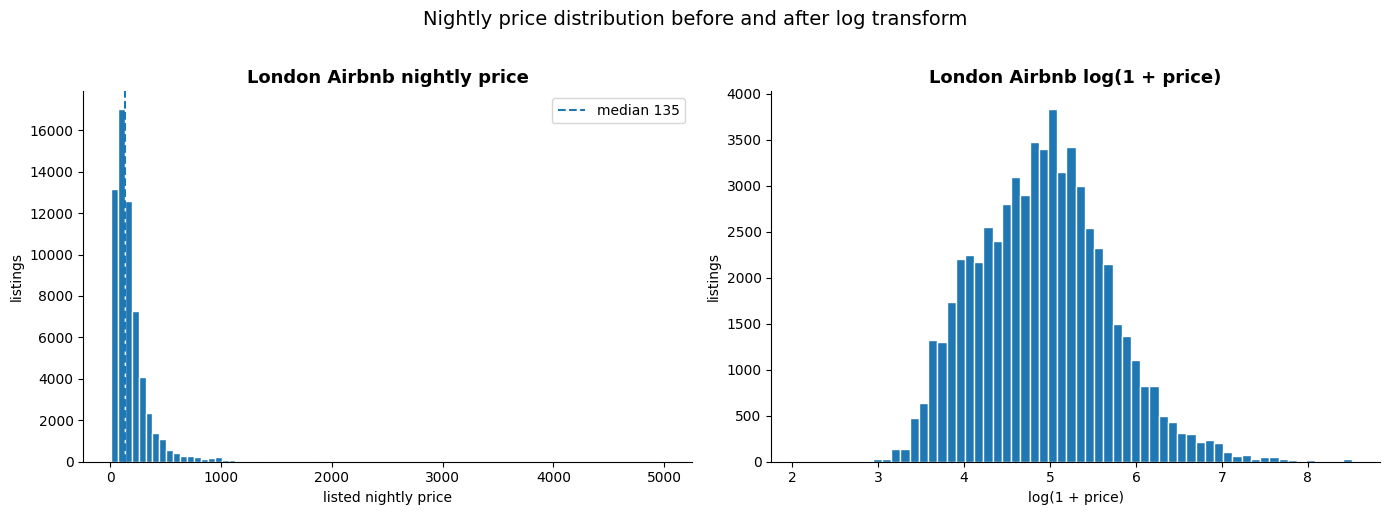

In [25]:
# Visual 1: price distribution, raw vs. log transformed!
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(df['price'], bins=80, edgecolor='white')
axes[0].axvline(df['price'].median(), linestyle='--', linewidth=1.5,
                label=f'median {df["price"].median():.0f}')
axes[0].set_title('London Airbnb nightly price', fontsize=13, fontweight='bold')
axes[0].set_xlabel('listed nightly price')
axes[0].set_ylabel('listings')
axes[0].legend()

axes[1].hist(df['log_price'], bins=60, edgecolor='white')
axes[1].set_title('London Airbnb log(1 + price)', fontsize=13, fontweight='bold')
axes[1].set_xlabel('log(1 + price)')
axes[1].set_ylabel('listings')

plt.suptitle('Nightly price distribution before and after log transform', y=1.02, fontsize=14)
plt.tight_layout()
plt.show()

Summary: Raw price is strongly right skewed. This means that small number of
luxury listings inflate the mean. The log transformation produces a roughly
symmetric, bell shaped distribution that is much better suited for linear
regression. This is why `log_price` is used as the modeling target. This lines up with our intuition, that there would be few expensive AirBNB's in the data set.

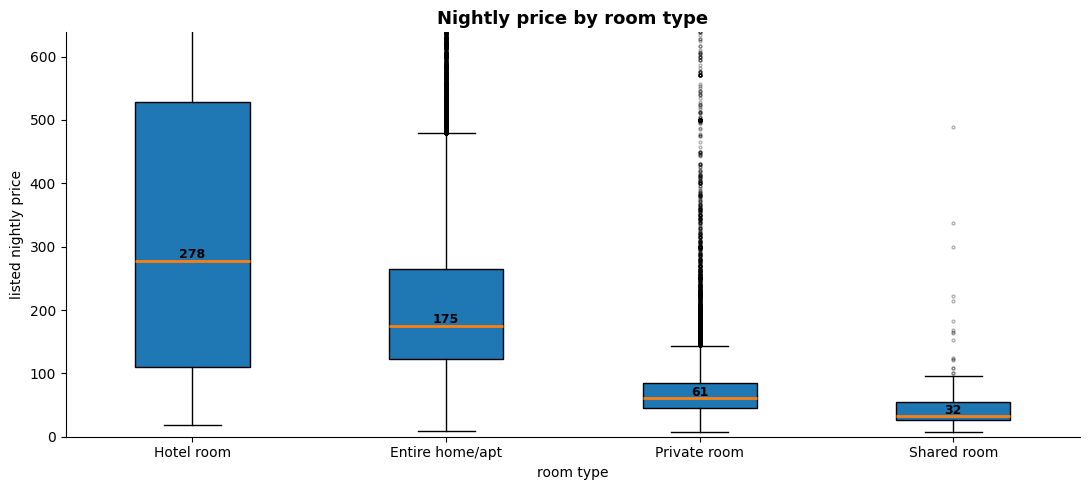

In [26]:
# Visual 2: price by room_type.
order = (
    df.groupby('room_type')['price']
    .median()
    .sort_values(ascending=False)
    .index.tolist()
)

fig, ax = plt.subplots(figsize=(11, 5))
groups = [df[df['room_type'] == rt]['price'].dropna().values for rt in order]
bp = ax.boxplot(
    groups, labels=order, patch_artist=True,
    medianprops=dict(linewidth=2),
    flierprops=dict(marker='o', markersize=2, alpha=0.3),
)

# to do: can u put medians so the plot is readable in the final presentation pls
for i, rt in enumerate(order, 1):
    med = df[df['room_type'] == rt]['price'].median()
    ax.text(i, med + 4, f'{med:.0f}', ha='center', fontsize=9, fontweight='bold')

ax.set_ylim(0, df['price'].quantile(0.97))
ax.set_title('Nightly price by room type', fontsize=13, fontweight='bold')
ax.set_xlabel('room type')
ax.set_ylabel('listed nightly price')
plt.tight_layout()
plt.show()

**Interpretation:** Entire home/apartment listings command the highest median
price, while shared rooms are cheapest, as expected. `room_type` is one of
the strongest predictors and must be included in every model. The wide spread
within each type signals that location and amenity factors add meaningful
variance on top of room type alone, which is exactly what our spatial
features are designed to capture. When we do coefficient analyzing, we expect that these features will be very prominent.

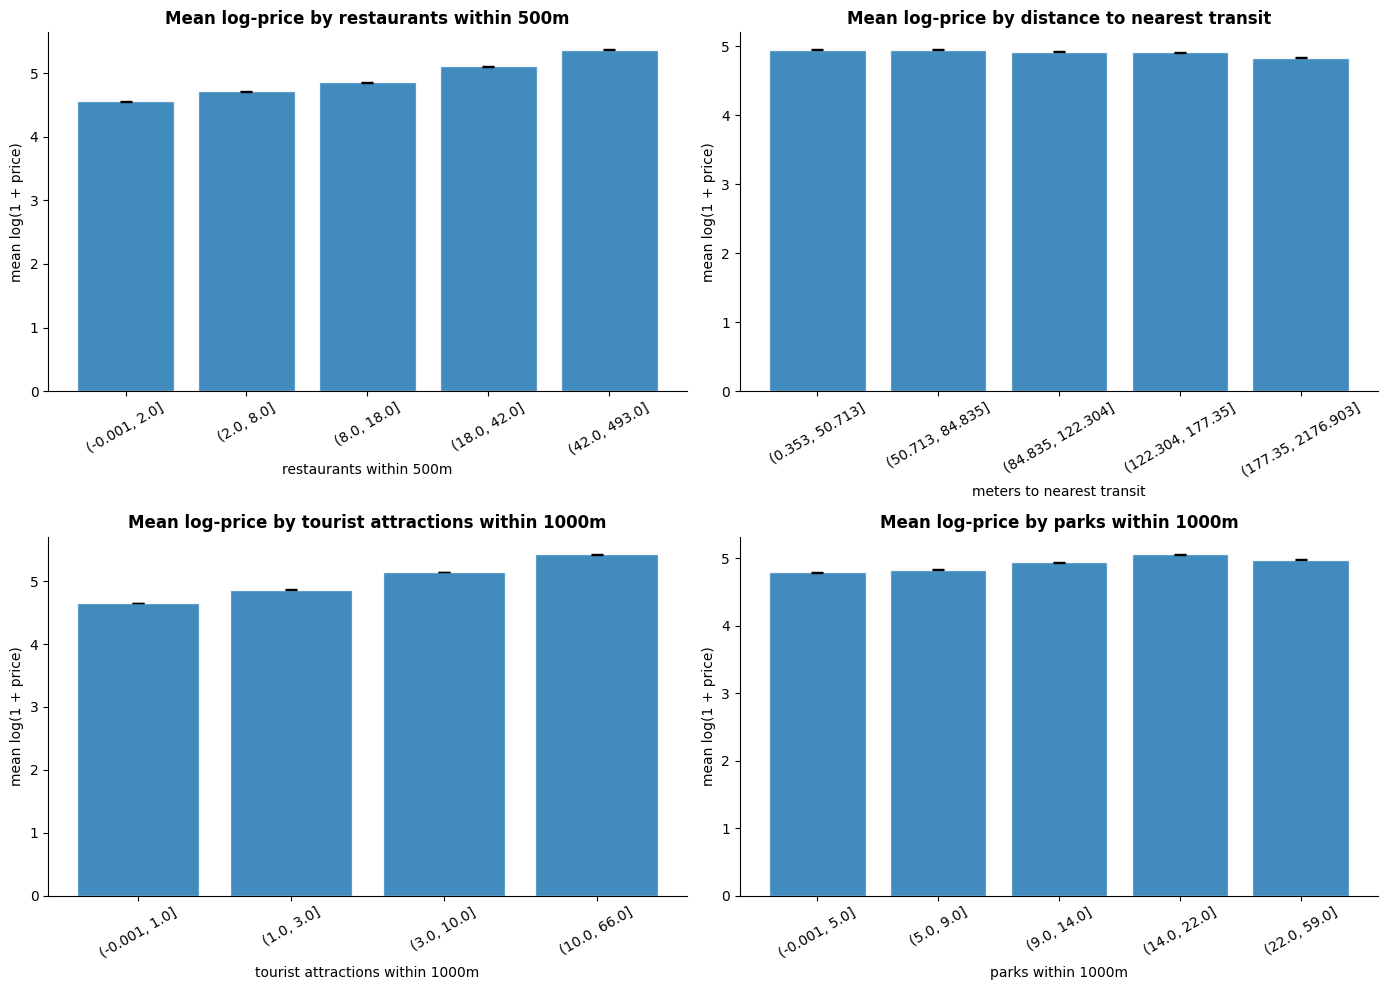

In [27]:
# Visual 3: log_price vs. geographic features.
#  panel bins a spatial variable and compares mean price and error

def plot_binned_mean(ax, col, title, xlabel, q=5):
    plot_df = df[[col, 'log_price']].dropna().copy()
    if plot_df.empty or plot_df[col].nunique() < 2:
        ax.set_title(f'{title} (not enough variation)', fontsize=12, fontweight='bold')
        ax.text(0.5, 0.5, 'not enough variation to plot', ha='center', va='center', transform=ax.transAxes)
        return

    # qcut adapts to each variable's distribution and avoids hand-picked cutoffs that may fail.
    plot_df['bin'] = pd.qcut(plot_df[col], q=min(q, plot_df[col].nunique()), duplicates='drop')
    grp = plot_df.groupby('bin', observed=True)['log_price'].agg(['mean', 'sem']).reset_index()
    labels = [str(x) for x in grp['bin']]

    ax.bar(labels, grp['mean'], yerr=grp['sem'], capsize=4, edgecolor='white', alpha=0.85)
    ax.set_title(title, fontsize=12, fontweight='bold')
    ax.set_xlabel(xlabel)
    ax.set_ylabel('mean log(1 + price)')
    ax.tick_params(axis='x', rotation=30)


fig, axes = plt.subplots(2, 2, figsize=(14, 10))
plot_binned_mean(axes[0, 0], 'restaurants_500m', 'Mean log-price by restaurants within 500m', 'restaurants within 500m')
plot_binned_mean(axes[0, 1], 'dist_nearest_transit', 'Mean log-price by distance to nearest transit', 'meters to nearest transit')
plot_binned_mean(axes[1, 0], 'tourist_attractions_1000m', 'Mean log-price by tourist attractions within 1000m', 'tourist attractions within 1000m')
plot_binned_mean(axes[1, 1], 'parks_1000m', 'Mean log-price by parks within 1000m', 'parks within 1000m')

plt.tight_layout()
plt.show()

**Panel A - Restaurant density:** Listings in areas with more restaurants tend to have higher prices. This fits the idea that restaurant density is a proxy for central, active, and visitor-friendly neighborhoods.

**Panel B - Transit proximity:** The transit relationship is weaker than we expected. A likely explanation is that London has dense transit coverage, so distance to the nearest stop has less variation than the other spatial variables.

**Panel C - Tourist attraction density:** Tourist-attraction density is one of the clearest positive relationships. Listings near museums, landmarks, galleries, and other points of interest likely face stronger visitor demand.

**Panel D - Park density:** Parks show a smaller relationship. This suggests green space may matter, but it is probably not as directly tied to short-term rental demand as room type or tourist density.

### 5b. Interactive map, correlation check, and SQL summaries

These cells add code that is useful for the final dashboard and explicitly uses Polars, SQL, joins, hypothesis testing, and supervised learning preparation.

In [28]:
# interactive map sample. this becomes a dashboard ready view of price and spatial context.
map_sample = df.sample(min(5000, len(df)), random_state=RANDOM_SEED).copy()

hover_cols = [c for c in ['neighbourhood_group', 'neighbourhood', 'room_type', 'price', 'restaurants_500m', 'tourist_attractions_1000m', 'transit_800m'] if c in map_sample.columns]

fig = px.scatter_mapbox(
    map_sample,
    lat='latitude',
    lon='longitude',
    color='log_price',
    hover_data=hover_cols,
    zoom=9,
    height=650,
    title='Interactive sample map of London Airbnb listings by log-price',
)
fig.update_layout(mapbox_style='open-street-map', margin=dict(l=0, r=0, t=40, b=0))
fig.show()

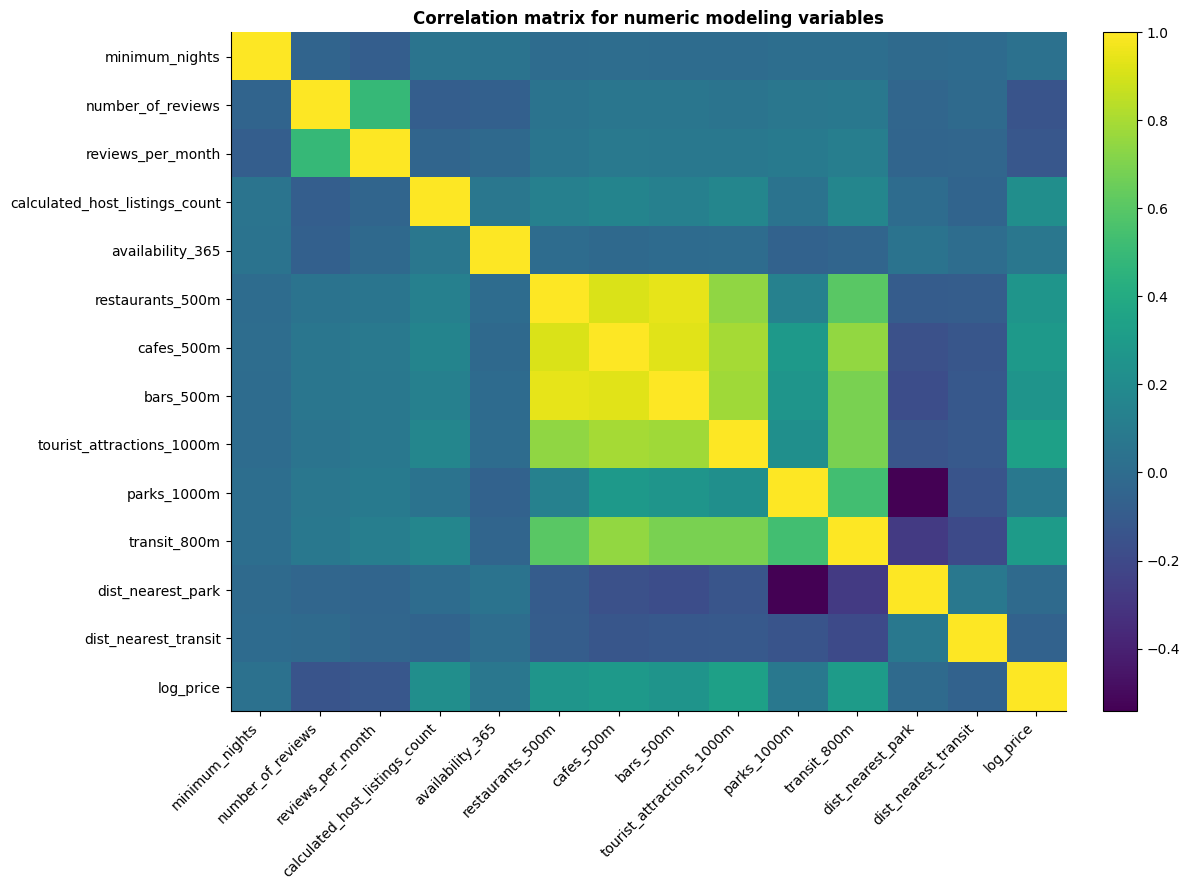

,feature_1,feature_2,correlation
1,restaurants_500m,bars_500m,0.9453
2,cafes_500m,bars_500m,0.9327
0,restaurants_500m,cafes_500m,0.9131


In [29]:
# to doL do a check among numeric predictors. high correlated predictors are flagged so
# we can justify using ridge regularization and tree models.
numeric_for_corr = [
    c for c in [
        'minimum_nights', 'number_of_reviews', 'reviews_per_month',
        'calculated_host_listings_count', 'availability_365',
        'restaurants_500m', 'cafes_500m', 'bars_500m',
        'tourist_attractions_1000m', 'parks_1000m', 'transit_800m',
        'dist_nearest_park', 'dist_nearest_transit', 'log_price'
    ]
    if c in df.columns
]

corr = df[numeric_for_corr].corr(numeric_only=True)

fig, ax = plt.subplots(figsize=(12, 9))
im = ax.imshow(corr, aspect='auto')
ax.set_xticks(range(len(corr.columns)))
ax.set_xticklabels(corr.columns, rotation=45, ha='right')
ax.set_yticks(range(len(corr.index)))
ax.set_yticklabels(corr.index)
fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
ax.set_title('Correlation matrix for numeric modeling variables', fontweight='bold')
plt.tight_layout()
plt.show()

# Print high-correlation pairs, excluding the diagonal.
high_corr_pairs = []
for i, col_i in enumerate(corr.columns):
    for j, col_j in enumerate(corr.columns):
        if j <= i:
            continue
        value = corr.loc[col_i, col_j]
        if abs(value) >= 0.80:
            high_corr_pairs.append((col_i, col_j, value))

high_corr_df = pd.DataFrame(high_corr_pairs, columns=['feature_1', 'feature_2', 'correlation']).sort_values('correlation', key=lambda s: s.abs(), ascending=False)
display(high_corr_df if not high_corr_df.empty else pd.DataFrame({'message': ['no feature pairs above |0.80|']}))

In [30]:
# ooh we can use this as a clean table for the presentation or dashboard.
pl_listings = pl.from_pandas(df)

# DuckDB can query a Pandas view registered from the Polars table
duckdb.register('listings', pl_listings.to_pandas())

neighbourhood_room_summary = duckdb.sql('''
    SELECT
        COALESCE(CAST(neighbourhood AS VARCHAR), 'Unknown') AS neighbourhood,
        COALESCE(CAST(room_type AS VARCHAR), 'Unknown') AS room_type,
        COUNT(*) AS listings,
        AVG(price) AS avg_price,
        MEDIAN(price) AS median_price,
        AVG(tourist_attractions_1000m) AS avg_tourist_attractions_1000m,
        AVG(restaurants_500m) AS avg_restaurants_500m,
        AVG(transit_800m) AS avg_transit_800m
    FROM listings
    GROUP BY 1, 2
    HAVING COUNT(*) >= 30
    ORDER BY median_price DESC, listings DESC
    LIMIT 20
''').df()

neighbourhood_room_summary

,neighbourhood,room_type,listings,avg_price,median_price,avg_tourist_attractions_1000m,avg_restaurants_500m,avg_transit_800m
0,City of London,Entire home/apt,383,331.7467,248.0000,27.3264,75.4465,273.3342
1,Westminster,Entire home/apt,7097,338.8568,245.0000,16.7390,101.5628,183.2735
2,Kensington and Chelsea,Entire home/apt,4220,327.6502,238.0000,9.0839,36.1083,106.0273
3,Camden,Entire home/apt,3150,247.2651,198.5000,19.0727,60.3873,177.1829
4,Wandsworth,Entire home/apt,2017,233.8949,183.0000,1.7387,13.6415,70.0327
5,Richmond upon Thames,Entire home/apt,540,239.2759,180.0000,1.6241,9.2111,46.0630
6,Hammersmith and Fulham,Entire home/apt,2052,226.3728,170.0000,1.1316,17.8309,87.9907
7,City of London,Private room,51,360.6863,169.0000,24.9412,85.8824,283.0784
8,Tower Hamlets,Entire home/apt,2757,209.5441,168.0000,6.0018,33.2971,148.5992
9,Islington,Entire home/apt,1980,205.6793,167.0000,5.5283,29.4066,154.5616


In [31]:
# hypoth test: are listings in tourist dense areas priced higher on the log scale?
# to do: compare the top quartile vs. bottom quartile of tourist-attraction density.
tourist_col = 'tourist_attractions_1000m'
q25 = df[tourist_col].quantile(0.25)
q75 = df[tourist_col].quantile(0.75)

low_tourist = df.loc[df[tourist_col] <= q25, 'log_price'].dropna()
high_tourist = df.loc[df[tourist_col] >= q75, 'log_price'].dropna()

t_stat, p_value = ttest_ind(high_tourist, low_tourist, equal_var=False)

hypothesis_result = pd.DataFrame({
    'group': ['low tourist density', 'high tourist density'],
    'n': [len(low_tourist), len(high_tourist)],
    'mean_log_price': [low_tourist.mean(), high_tourist.mean()],
    'median_log_price': [low_tourist.median(), high_tourist.median()],
})

display(hypothesis_result)
print(f'Welch t-test: t = {t_stat:.3f}, p = {p_value:.4g}')

if p_value < 0.05:
    print('The difference is statistically significant at the 5% level.')
else:
    print('The difference is not statistically significant at the 5% level.')

,group,n,mean_log_price,median_log_price
0,low tourist density,19641,4.6153,4.5951
1,high tourist density,17020,5.3469,5.3375


Welch t-test: t = 96.481, p = 0
The difference is statistically significant at the 5% level.


### EDA Findings That Informed Modeling

The exploratory analysis directly informed the modeling choices used later in the notebook.

| Finding | Evidence from EDA | Modeling decision |
|---|---|---|
| Price is strongly right-skewed | The raw price histogram has a long right tail, and the price summary shows that the 99th percentile and maximum are much higher than the median listing price. | Use `log_price = log(1 + price)` as the prediction target instead of raw price. This reduces the influence of extreme listings and makes model errors more stable. |
| Room type strongly affects price | The room-type boxplot shows clear differences in median nightly price across entire homes, private rooms, hotel rooms, and shared rooms. | Include `room_type` as a categorical feature and one-hot encode it in the preprocessing pipeline. |
| Tourist-attraction and restaurant density are related to price | The binned spatial plots show that listings with more nearby restaurants and tourist attractions tend to have higher average log-price. | Engineer spatial POI count features such as `restaurants_500m`, `cafes_500m`, `bars_500m`, and `tourist_attractions_1000m`. |
| Some nearby amenity counts are highly correlated | The correlation matrix shows that restaurant, cafe, and bar counts move together because they all measure dense commercial/visitor areas. | Use Ridge regression to handle correlated predictors through regularization, and also test Random Forest because it can capture nonlinear relationships among spatial features. |
| Transit proximity has a weaker relationship than expected | The binned plot for nearest transit distance shows a less clear price pattern than restaurant or tourist-attraction density. | Keep transit features, but let the models decide their importance rather than assuming transit is the dominant geographic predictor. |
| Location and amenity effects are likely not purely linear | The binned plots show changes in average log-price across feature ranges, but the relationships are not perfectly straight lines. | Compare a baseline linear model with Ridge interactions and Random Forest to test whether more flexible models improve prediction. |

---
## 6. Modeling Setup and Baseline Linear Regression

**Target:** `log_price`

We predict log nightly price rather than raw price because the target is highly right-skewed. All preprocessing steps that learn from the data, including imputation, scaling, one-hot encoding, polynomial interactions, and model fitting, happen inside scikit-learn pipelines after the train-test split. That avoids leakage from the test set.

In [32]:
# we can set up feature groups and train test split.
# wait should we just split randomly - shishir
# ya go for it
NUMERIC_FEATURES = [
    'minimum_nights', 'number_of_reviews', 'reviews_per_month',
    'calculated_host_listings_count', 'availability_365',
    'restaurants_500m', 'cafes_500m', 'bars_500m',
    'tourist_attractions_1000m', 'parks_1000m', 'transit_800m',
    'dist_nearest_park', 'dist_nearest_transit',
]
CAT_FEATURES_ORIG = ['room_type', 'neighbourhood_group']

NUMERIC_FEATURES = [c for c in NUMERIC_FEATURES if c in df.columns]
CAT_FEATURES = [c for c in CAT_FEATURES_ORIG if c in df.columns and not df[c].dropna().empty]
TARGET = 'log_price'

model_df = df[NUMERIC_FEATURES + CAT_FEATURES + [TARGET]].dropna(subset=[TARGET]).copy()
X = model_df[NUMERIC_FEATURES + CAT_FEATURES]
y = model_df[TARGET]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=RANDOM_SEED
)

print(f'numeric features: {NUMERIC_FEATURES}')
print(f'categorical features: {CAT_FEATURES}')
print(f'train: {X_train.shape}  |  test: {X_test.shape}')

numeric features: ['minimum_nights', 'number_of_reviews', 'reviews_per_month', 'calculated_host_listings_count', 'availability_365', 'restaurants_500m', 'cafes_500m', 'bars_500m', 'tourist_attractions_1000m', 'parks_1000m', 'transit_800m', 'dist_nearest_park', 'dist_nearest_transit']
categorical features: ['room_type']
train: (49486, 14)  |  test: (12372, 14)


In [33]:
#  pipeline: impute, scale or encode, then fit a linear regression
# sounds good!
def make_one_hot_encoder():
    '''Create a dense OneHotEncoder that works across sklearn versions.'''
    try:
        return OneHotEncoder(handle_unknown='ignore', sparse_output=False)
    except TypeError:
        return OneHotEncoder(handle_unknown='ignore', sparse=False)


numeric_tf = Pipeline([
    ('impute', SimpleImputer(strategy='median')),
    ('scale', StandardScaler()),
])
cat_tf = Pipeline([
    ('impute', SimpleImputer(strategy='most_frequent')),
    ('encode', make_one_hot_encoder()),
])
preprocessor = ColumnTransformer([
    ('num', numeric_tf, NUMERIC_FEATURES),
    ('cat', cat_tf, CAT_FEATURES),
])

baseline_model = Pipeline([
    ('prep', preprocessor),
    ('model', LinearRegression()),
])

baseline_model.fit(X_train, y_train)
model = baseline_model  # keep this alias so earlier coefficient cells still work.
print('baseline linear regression trained.')

#ok yay this looks good leave it in

baseline linear regression trained.


=== Baseline Linear Regression ===
train RMSE log: 0.5580 | train R²: 0.4759
test  RMSE log: 0.5618 | test  R²: 0.4663
test  MAE  log: 0.4176
test  MAE price units: 87.12


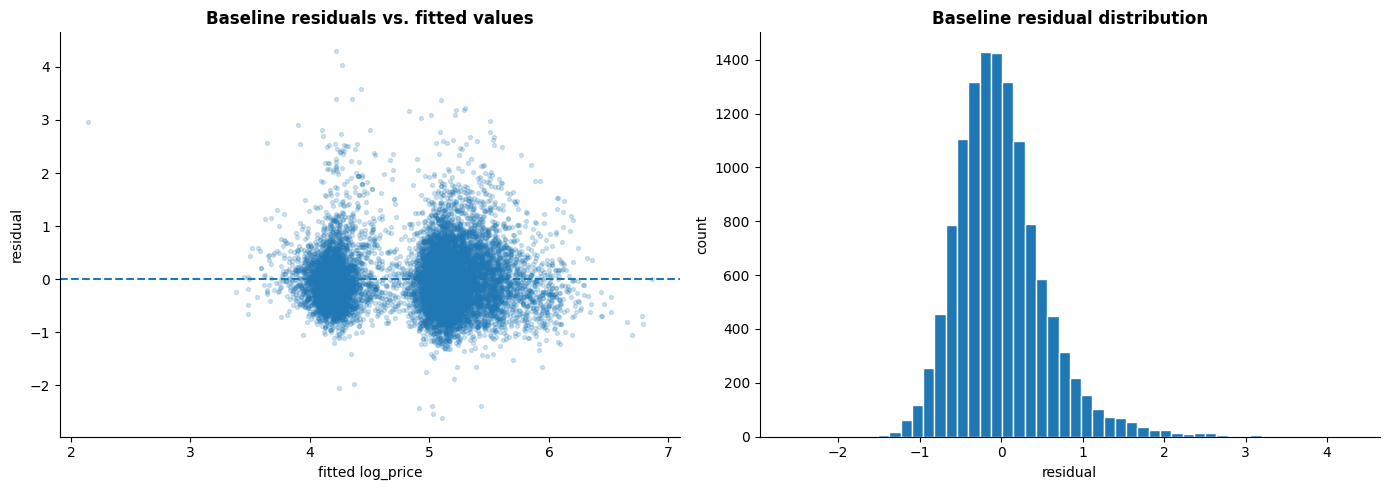

In [34]:
# to do: helpers and baseline evaluation.
def regression_metrics(name, fitted_model, X_tr, X_te, y_tr, y_te):
    pred_train = fitted_model.predict(X_tr)
    pred_test = fitted_model.predict(X_te)

    return {
        'model': name,
        'train_rmse_log': np.sqrt(mean_squared_error(y_tr, pred_train)),
        'test_rmse_log': np.sqrt(mean_squared_error(y_te, pred_test)),
        'train_mae_log': mean_absolute_error(y_tr, pred_train),
        'test_mae_log': mean_absolute_error(y_te, pred_test),
        'test_median_ae_log': median_absolute_error(y_te, pred_test),
        'train_r2': r2_score(y_tr, pred_train),
        'test_r2': r2_score(y_te, pred_test),
        'test_mae_price_units': mean_absolute_error(np.expm1(y_te), np.expm1(pred_test)),
    }


def print_metrics(metrics):
    print(f"=== {metrics['model']} ===")
    print(f"train RMSE log: {metrics['train_rmse_log']:.4f} | train R²: {metrics['train_r2']:.4f}")
    print(f"test  RMSE log: {metrics['test_rmse_log']:.4f} | test  R²: {metrics['test_r2']:.4f}")
    print(f"test  MAE  log: {metrics['test_mae_log']:.4f}")
    print(f"test  MAE price units: {metrics['test_mae_price_units']:.2f}")


model_scores = {}
model_scores['Baseline Linear Regression'] = regression_metrics(
    'Baseline Linear Regression', baseline_model, X_train, X_test, y_train, y_test
)
print_metrics(model_scores['Baseline Linear Regression'])

# residual plots for the baseline model.
y_pred_test = baseline_model.predict(X_test)
residuals = y_test.values - y_pred_test

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].scatter(y_pred_test, residuals, alpha=0.2, s=8)
axes[0].axhline(0, linestyle='--', linewidth=1.5)
axes[0].set_title('Baseline residuals vs. fitted values', fontweight='bold')
axes[0].set_xlabel('fitted log_price')
axes[0].set_ylabel('residual')

axes[1].hist(residuals, bins=50, edgecolor='white')
axes[1].set_title('Baseline residual distribution', fontweight='bold')
axes[1].set_xlabel('residual')
axes[1].set_ylabel('count')

plt.tight_layout()
plt.show()

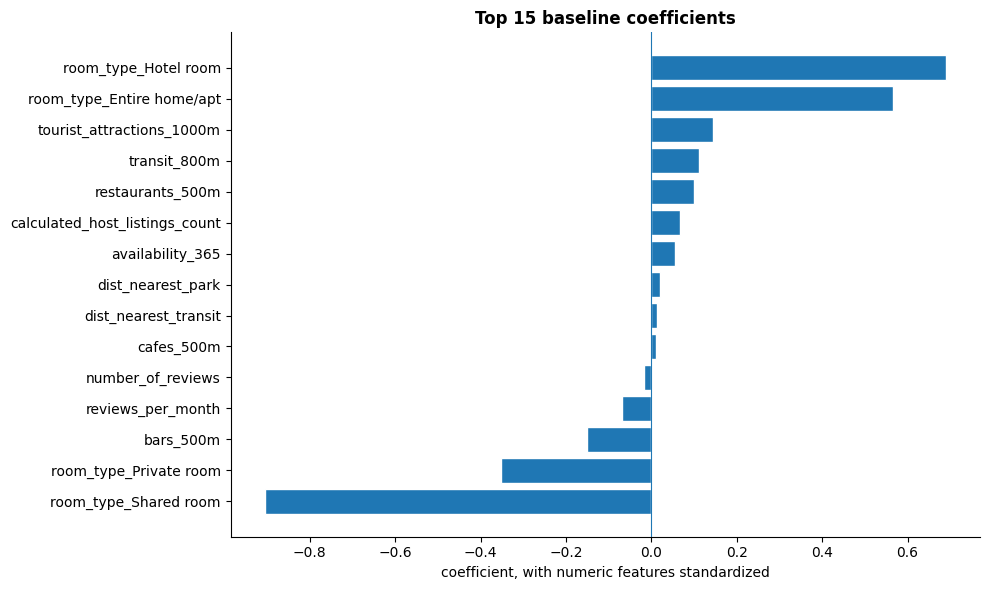

,feature,coef,abs_coef
16,room_type_Shared room,-0.9055,0.9055
14,room_type_Hotel room,0.6899,0.6899
13,room_type_Entire home/apt,0.5670,0.5670
15,room_type_Private room,-0.3514,0.3514
7,bars_500m,-0.1500,0.1500
8,tourist_attractions_1000m,0.1456,0.1456
10,transit_800m,0.1107,0.1107
5,restaurants_500m,0.0997,0.0997
2,reviews_per_month,-0.0688,0.0688
3,calculated_host_listings_count,0.0682,0.0682


In [35]:
# find the baseline linear model through standardized coefficients.
def get_feature_names_from_pipeline(fitted_pipeline, numeric_features, categorical_features):
    '''Return readable feature names from the fitted ColumnTransformer inside a pipeline.'''
    prep = fitted_pipeline.named_steps['prep']
    names = []

    for transformer_name, transformer, cols in prep.transformers_:
        if transformer == 'drop':
            continue
        if transformer_name == 'num':
            # if this numeric pipeline includes PolynomialFeatures, use those expanded names.
            # ok sg
            if hasattr(transformer, 'named_steps') and 'poly' in transformer.named_steps:
                names.extend(transformer.named_steps['poly'].get_feature_names_out(cols))
            else:
                names.extend(cols)
        elif transformer_name == 'cat':
            encoder = transformer.named_steps.get('encode') if hasattr(transformer, 'named_steps') else None
            if encoder is not None:
                names.extend(encoder.get_feature_names_out(cols))
            else:
                names.extend(cols)
        else:
            names.extend(cols)

    return list(names)


all_names = get_feature_names_from_pipeline(baseline_model, NUMERIC_FEATURES, CAT_FEATURES)
coefs = baseline_model.named_steps['model'].coef_

coef_df = (
    pd.DataFrame({'feature': all_names, 'coef': coefs})
    .assign(abs_coef=lambda d: d['coef'].abs())
    .sort_values('abs_coef', ascending=False)
    .head(15)
    .sort_values('coef')
)

fig, ax = plt.subplots(figsize=(10, 6))
ax.barh(coef_df['feature'], coef_df['coef'], edgecolor='white')
ax.axvline(0, linewidth=0.8)
ax.set_title('Top 15 baseline coefficients', fontweight='bold')
ax.set_xlabel('coefficient, with numeric features standardized')
plt.tight_layout()
plt.show()

coef_df.sort_values('abs_coef', ascending=False).head(15)

### What the baseline results mean

The baseline is intentionally simple and interpretable. It tells us how much of price variation can be explained by listing attributes and spatial features under a linear-additive assumption.

**What to look for:**
- `room_type` coefficients are expected to be among the largest because entire homes generally command higher prices than shared or private rooms.
- Spatial coefficients such as `tourist_attractions_1000m`, `restaurants_500m`, and `dist_nearest_transit` directly address the research question.
- Residual plots show whether the linear model misses nonlinear patterns, which motivates ridge interactions and a random forest.

---
## 7. Additional Models, Hyperparameter Tuning, and Model Comparison

We complete two stronger models beyond the baseline:

1. **Ridge regression with interaction terms** - adds numeric interaction features and tunes regularization strength. This tests whether spatial factors matter through combinations, such as restaurant density and transit access together.
2. **Random forest regression** - an ensemble model that captures nonlinear effects and provides feature importance.

Hyperparameter tuning is done with cross-validation on the training set only. The test set is used once at the end for final comparison.

In [36]:
# Model 2: Ridge regression with numeric interaction terms and tuned alpha
# The PolynomialFeatures step is inside the pipeline, so it is fit on training folds only during CV.
numeric_interaction_tf = Pipeline([
    ('impute', SimpleImputer(strategy='median')),
    ('poly', PolynomialFeatures(degree=2, interaction_only=True, include_bias=False)),
    ('scale', StandardScaler()),
])

ridge_preprocessor = ColumnTransformer([
    ('num', numeric_interaction_tf, NUMERIC_FEATURES),
    ('cat', cat_tf, CAT_FEATURES),
])

ridge_pipe = Pipeline([
    ('prep', ridge_preprocessor),
    ('model', Ridge(max_iter=10_000)),
])

cv = KFold(n_splits=3, shuffle=True, random_state=RANDOM_SEED)

ridge_search = RandomizedSearchCV(
    ridge_pipe,
    param_distributions={'model__alpha': loguniform(1e-3, 1e3)},
    n_iter=25,
    scoring='neg_root_mean_squared_error',
    cv=cv,
    random_state=RANDOM_SEED,
    n_jobs=-1,
    verbose=1,
)

ridge_search.fit(X_train, y_train)
ridge_model = ridge_search.best_estimator_

print('best ridge params:', ridge_search.best_params_)
print(f"best CV RMSE log: {-ridge_search.best_score_:.4f}")

model_scores['Ridge + Numeric Interactions'] = regression_metrics(
    'Ridge + Numeric Interactions', ridge_model, X_train, X_test, y_train, y_test
)
print_metrics(model_scores['Ridge + Numeric Interactions'])

Fitting 3 folds for each of 25 candidates, totalling 75 fits
best ridge params: {'model__alpha': np.float64(3.907967156822881)}
best CV RMSE log: 0.5443
=== Ridge + Numeric Interactions ===
train RMSE log: 0.5418 | train R²: 0.5058
test  RMSE log: 0.5480 | test  R²: 0.4922
test  MAE  log: 0.4062
test  MAE price units: 87.65


### 7b. Tuned Random Forest Regressor

Random forest is our main nonlinear ensemble model. We tune tree depth, leaf size, feature subsampling, and number of trees with randomized search. This gives us a methodical tuning process without using the test set for model selection.

In [37]:
rf_pipe = Pipeline(
    [('prep', preprocessor), ('model', RandomForestRegressor(random_state=RANDOM_SEED, n_jobs=-1, bootstrap=True))]
)

rf_param_dist = {
    'model__n_estimators': [50],
    'model__max_depth': [10, 15],
    'model__min_samples_leaf': [5, 10],
    'model__max_features': ['sqrt'],
}

rf_search = RandomizedSearchCV(
    rf_pipe,
    param_distributions=rf_param_dist,
    n_iter=3,
    scoring='neg_root_mean_squared_error',
    cv=cv,
    random_state=RANDOM_SEED,
    n_jobs=-1,
    verbose=1,
)

rf_search.fit(X_train, y_train)
rf_model = rf_search.best_estimator_

print('best random forest params:', rf_search.best_params_)
print(f"best CV RMSE log: {-rf_search.best_score_:.4f}")

model_scores['Tuned Random Forest'] = regression_metrics(
    'Tuned Random Forest', rf_model, X_train, X_test, y_train, y_test
)
print_metrics(model_scores['Tuned Random Forest'])

Fitting 3 folds for each of 3 candidates, totalling 9 fits
best random forest params: {'model__n_estimators': 50, 'model__min_samples_leaf': 10, 'model__max_features': 'sqrt', 'model__max_depth': 15}
best CV RMSE log: 0.5045
=== Tuned Random Forest ===
train RMSE log: 0.4475 | train R²: 0.6629
test  RMSE log: 0.4998 | test  R²: 0.5775
test  MAE  log: 0.3697
test  MAE price units: 78.36


### 7c. Model comparison

The best model should be chosen primarily by test RMSE and MAE on the log-price target, while also considering interpretability. The price-unit MAE is included because it is easier to communicate to stakeholders.

In [38]:
# to do: compare all models in one table

# done!!
results_df = (
    pd.DataFrame(model_scores.values())
    .sort_values('test_rmse_log')
    .reset_index(drop=True)
)

results_df

,model,train_rmse_log,test_rmse_log,train_mae_log,test_mae_log,test_median_ae_log,train_r2,test_r2,test_mae_price_units
0,Tuned Random Forest,0.4475,0.4998,0.3309,0.3697,0.2922,0.6629,0.5775,78.3638
1,Ridge + Numeric Interactions,0.5418,0.5480,0.4040,0.4062,0.3233,0.5058,0.4922,87.6519
2,Baseline Linear Regression,0.5580,0.5618,0.4175,0.4176,0.3318,0.4759,0.4663,87.1229


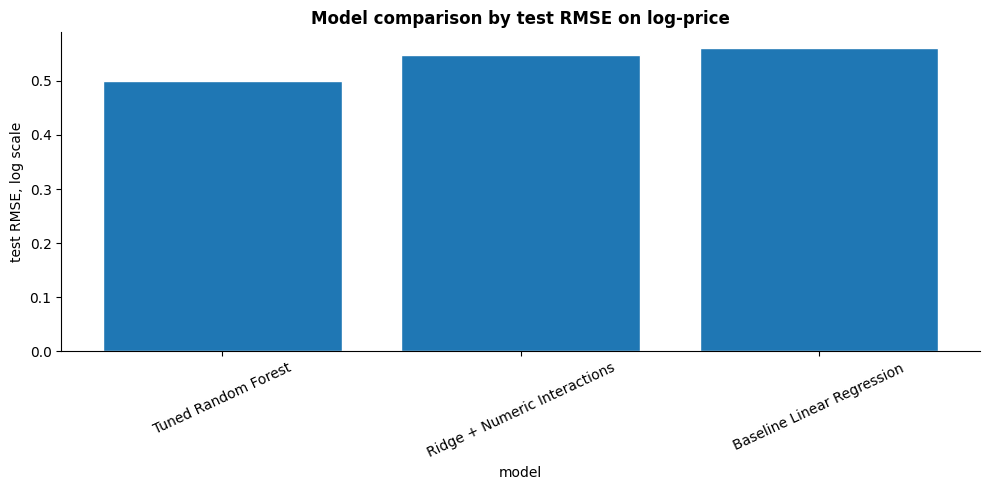

In [39]:
# Visual comparison of model performance.
fig, ax = plt.subplots(figsize=(10, 5))
ax.bar(results_df['model'], results_df['test_rmse_log'], edgecolor='white')
ax.set_title('Model comparison by test RMSE on log-price', fontweight='bold')
ax.set_xlabel('model')
ax.set_ylabel('test RMSE, log scale')
ax.tick_params(axis='x', rotation=25)
plt.tight_layout()
plt.show()

### 7d. Feature importance and interpretation

We report two forms of model interpretation:

- Random forest impurity-based importance gives a quick ranking of transformed features.
- Permutation importance measures how much model performance worsens when each original feature is shuffled on held-out data.

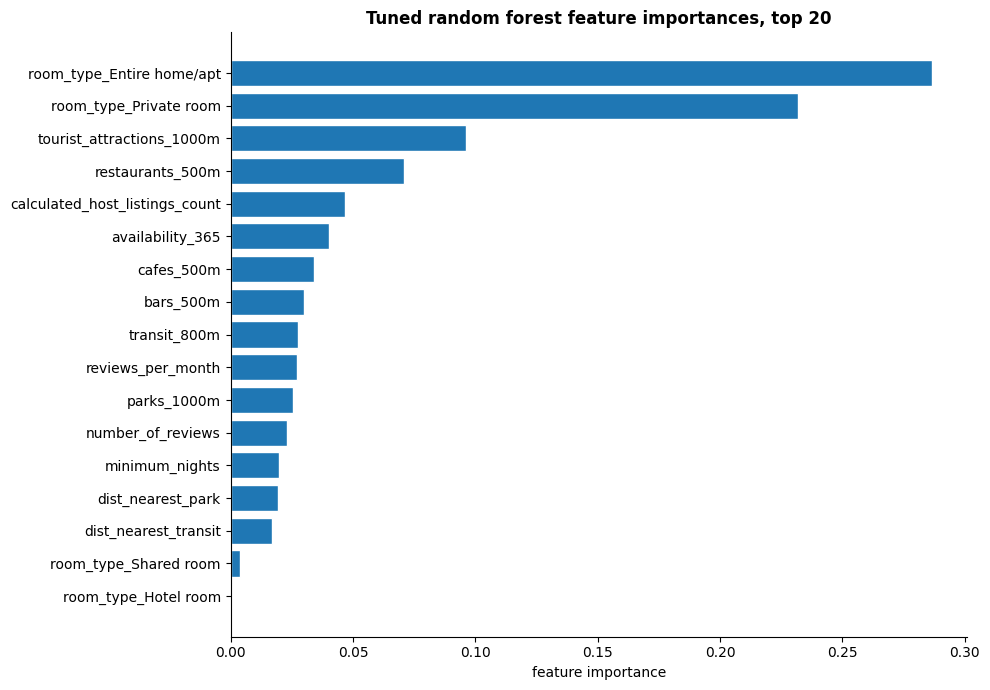

,feature,importance
0,room_type_Entire home/apt,0.2867
1,room_type_Private room,0.2320
2,tourist_attractions_1000m,0.0963
3,restaurants_500m,0.0708
4,calculated_host_listings_count,0.0468
5,availability_365,0.0404
6,cafes_500m,0.0341
7,bars_500m,0.0300
8,transit_800m,0.0274
9,reviews_per_month,0.0269


In [40]:
# tree feature importance from the tuned random forest
rf_feature_names = get_feature_names_from_pipeline(rf_model, NUMERIC_FEATURES, CAT_FEATURES)
rf_importances = rf_model.named_steps['model'].feature_importances_

rf_importance_df = (
    pd.DataFrame({'feature': rf_feature_names, 'importance': rf_importances})
    .sort_values('importance', ascending=False)
    .reset_index(drop=True)
)

fig, ax = plt.subplots(figsize=(10, 7))
plot_df = rf_importance_df.head(20).sort_values('importance')
ax.barh(plot_df['feature'], plot_df['importance'], edgecolor='white')
ax.set_title('Tuned random forest feature importances, top 20', fontweight='bold')
ax.set_xlabel('feature importance')
plt.tight_layout()
plt.show()

rf_importance_df.head(20)

# should we also graph increase rmse below...

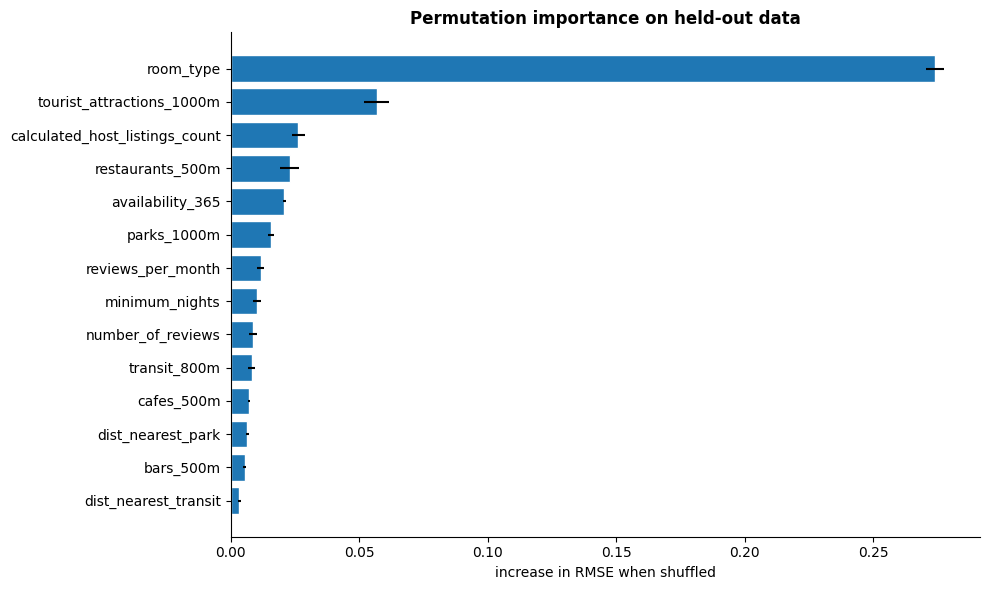

,feature,importance_mean,importance_std
0,room_type,0.2742,0.0035
1,tourist_attractions_1000m,0.0568,0.0048
2,calculated_host_listings_count,0.0263,0.0025
3,restaurants_500m,0.0230,0.0037
4,availability_365,0.0209,0.0007
5,parks_1000m,0.0157,0.0012
6,reviews_per_month,0.0117,0.0015
7,minimum_nights,0.0104,0.0016
8,number_of_reviews,0.0088,0.0015
9,transit_800m,0.0082,0.0012


In [41]:
# permuitation importance on a sample


perm_n = min(2000, len(X_test))
X_perm = X_test.sample(perm_n, random_state=RANDOM_SEED)
y_perm = y_test.loc[X_perm.index]

perm = permutation_importance(
    rf_model,
    X_perm,
    y_perm,
    n_repeats=5,
    random_state=RANDOM_SEED,
    scoring='neg_root_mean_squared_error',
    n_jobs=-1,
)

perm_importance_df = (
    pd.DataFrame({
        'feature': X_perm.columns,
        'importance_mean': perm.importances_mean,
        'importance_std': perm.importances_std,
    })
    .sort_values('importance_mean', ascending=False)
    .reset_index(drop=True)
)

fig, ax = plt.subplots(figsize=(10, 6))
plot_df = perm_importance_df.head(15).sort_values('importance_mean')
ax.barh(plot_df['feature'], plot_df['importance_mean'], xerr=plot_df['importance_std'], edgecolor='white')
ax.set_title('Permutation importance on held-out data', fontweight='bold')
ax.set_xlabel('increase in RMSE when shuffled')
plt.tight_layout()
plt.show()

perm_importance_df.head(15)

---
## 8. Save Project Artifacts for the Dashboard

Here we just save the project artifacts, since the dashboard should not have to rebuild all spatial joins and train all models every time it starts.

In [42]:
# Pick the best model by test RMSE and save the artifacts used by the dashboard.
best_model_name = results_df.iloc[0]['model']
best_model_lookup = {
    'Baseline Linear Regression': baseline_model,
    'Ridge + Numeric Interactions': ridge_model,
    'Tuned Random Forest': rf_model,
}
best_model = best_model_lookup[best_model_name]

# looks good
df.to_csv(OUTPUT_DIR / 'modeling_data.csv', index=False)
results_df.to_csv(OUTPUT_DIR / 'model_results.csv', index=False)
rf_importance_df.to_csv(OUTPUT_DIR / 'rf_feature_importance.csv', index=False)
perm_importance_df.to_csv(OUTPUT_DIR / 'permutation_importance.csv', index=False)

joblib.dump(best_model, OUTPUT_DIR / 'best_airbnb_price_model.joblib')

metadata = {
    'best_model_name': best_model_name,
    'target': TARGET,
    'numeric_features': NUMERIC_FEATURES,
    'categorical_features': CAT_FEATURES,
    'spatial_features': SPATIAL_COLS,
    'random_seed': RANDOM_SEED,
}
with open(OUTPUT_DIR / 'model_metadata.json', 'w') as f:
    json.dump(metadata, f, indent=2)

print(f'best model: {best_model_name}')
print(f'artifacts saved to: {OUTPUT_DIR}')
print('\n'.join(sorted(os.listdir(OUTPUT_DIR))))

best model: Tuned Random Forest
artifacts saved to: /content/airbnb_project_outputs
best_airbnb_price_model.joblib
model_metadata.json
model_results.csv
modeling_data.csv
permutation_importance.csv
rf_feature_importance.csv


## 9. Dashboard App Code

This section creates the Streamlit dashboard app for our project. The app uses the cleaned Airbnb data, exported model results, feature importance file, and saved final model to build an interactive dashboard.

Run the app locally or in Colab with:

```bash
streamlit run app.py

We decided to organize the dashboard into 5 main tabs so the project is easier to understand and use. Instead of putting every chart, map, and model result on one long page, the tabs separate the analysis into clear sections. This makes the dashboard feel more like a real data product and helps the user move from general exploration to model results and finally to price prediction.

In [43]:
# write dashboard app to disk.
# ok i will write the polished dashboard app
from pathlib import Path

#we should add some fun things to dash board like color, emoji, etc.

#bruh how do u code in streamlit lol - shishir

# wait streamlit is goated lol here https://docs.streamlit.io/
#i used to use this so much in hs for hackathons lol - crystal
app_code = r'''
import json
from pathlib import Path

import joblib
import numpy as np
import pandas as pd
import plotly.express as px
import plotly.graph_objects as go
import streamlit as st

st.set_page_config(
    page_title="London Airbnb Pricing Dashboard",
    page_icon="🏠",
    layout="wide",
    initial_sidebar_state="expanded",
)

st.markdown(
    """
    <style>
    .main .block-container {
        padding-top: 1.5rem;
        padding-bottom: 2rem;
        max-width: 1400px;
    }
    .hero-card {
        padding: 1.4rem 1.6rem;
        border-radius: 1.2rem;
        background: linear-gradient(135deg, #f8fafc 0%, #eef2ff 100%);
        border: 1px solid #e5e7eb;
        box-shadow: 0 8px 24px rgba(15, 23, 42, 0.06);
        margin-bottom: 1rem;
    }
    .hero-title {
        font-size: 2.1rem;
        font-weight: 800;
        color: #111827;
        margin-bottom: 0.2rem;
    }
    .hero-subtitle {
        font-size: 1rem;
        color: #4b5563;
        line-height: 1.55;
        max-width: 1050px;
    }
    .insight-card {
        padding: 1rem 1.1rem;
        border-radius: 1rem;
        background: #ffffff;
        border: 1px solid #e5e7eb;
        box-shadow: 0 6px 20px rgba(15, 23, 42, 0.05);
        min-height: 120px;
    }
    .insight-card h4 {
        margin: 0 0 0.4rem 0;
        color: #111827;
        font-size: 1rem;
    }
    .insight-card p {
        margin: 0;
        color: #4b5563;
        font-size: 0.92rem;
        line-height: 1.45;
    }
    div[data-testid="stMetricValue"] {
        font-size: 1.65rem;
        font-weight: 800;
    }
    div[data-testid="stMetricLabel"] {
        font-size: 0.9rem;
    }
    .stTabs [data-baseweb="tab-list"] {
        gap: 0.5rem;
    }
    .stTabs [data-baseweb="tab"] {
        border-radius: 999px;
        padding: 0.45rem 0.9rem;
        background-color: #f3f4f6;
    }
    </style>
    """,
    unsafe_allow_html=True,
)

BASE_DIR = Path(__file__).resolve().parent if "__file__" in globals() else Path.cwd()

CANDIDATE_OUTPUT_DIRS = [
    BASE_DIR / "airbnb_project_outputs",
    Path("/content/airbnb_project_outputs"),
    Path.cwd() / "airbnb_project_outputs",
]

OUTPUT_DIR = next((p for p in CANDIDATE_OUTPUT_DIRS if p.exists()), CANDIDATE_OUTPUT_DIRS[0])

REQUIRED_TABLES = [
    "modeling_data.csv",
    "model_results.csv",
    "rf_feature_importance.csv",
    "permutation_importance.csv",
    "model_metadata.json",
]


def fmt_money(x):
    if pd.isna(x):
        return "n/a"
    return f"£{x:,.0f}"


def fmt_num(x, digits=2):
    if pd.isna(x):
        return "n/a"
    return f"{x:,.{digits}f}"


def first_existing(columns, candidates):
    for c in candidates:
        if c in columns:
            return c
    return None


@st.cache_data(show_spinner=False)
def load_tables(output_dir_str):
    output_dir = Path(output_dir_str)
    data = pd.read_csv(output_dir / "modeling_data.csv")
    results = pd.read_csv(output_dir / "model_results.csv")
    rf_imp = pd.read_csv(output_dir / "rf_feature_importance.csv")
    perm_imp = pd.read_csv(output_dir / "permutation_importance.csv")

    with open(output_dir / "model_metadata.json", "r") as f:
        metadata = json.load(f)

    return data, results, rf_imp, perm_imp, metadata


@st.cache_resource(show_spinner=False)
def load_model(output_dir_str):
    model_path = Path(output_dir_str) / "best_airbnb_price_model.joblib"
    if not model_path.exists():
        return None
    return joblib.load(model_path)


missing = [name for name in REQUIRED_TABLES if not (OUTPUT_DIR / name).exists()]

if missing:
    st.error(
        "Dashboard artifacts are missing. Run the notebook through the artifact export cell before launching the dashboard."
    )
    st.markdown("Missing files: " + ", ".join(f"`{m}`" for m in missing))
    st.markdown(f"Expected folder: `{OUTPUT_DIR}`")
    st.stop()

try:
    df, results_df, rf_importance_df, perm_importance_df, metadata = load_tables(str(OUTPUT_DIR))
    best_model = load_model(str(OUTPUT_DIR))
except Exception as exc:
    st.error("The dashboard artifacts exist, but one or more could not be loaded.")
    st.exception(exc)
    st.stop()

# Defensive column cleanup.
for col in ["price", "log_price", "latitude", "longitude"]:
    if col in df.columns:
        df[col] = pd.to_numeric(df[col], errors="coerce")

if "log_price" not in df.columns and "price" in df.columns:
    df["log_price"] = np.log1p(df["price"].clip(lower=0))

if "price" not in df.columns and "log_price" in df.columns:
    df["price"] = np.expm1(df["log_price"])

numeric_features = [c for c in metadata.get("numeric_features", []) if c in df.columns]
categorical_features = [c for c in metadata.get("categorical_features", []) if c in df.columns]
spatial_features = [c for c in metadata.get("spatial_features", []) if c in df.columns]
best_model_name = metadata.get("best_model_name", "best available model")

borough_col = first_existing(
    df.columns,
    ["neighbourhood_group", "neighbourhood_cleansed", "neighbourhood", "borough"],
)

room_col = "room_type" if "room_type" in df.columns else None

# Sidebar filters.
st.sidebar.markdown("## Dashboard controls")
st.sidebar.caption("Use the filters to explore how pricing patterns change across the London market.")

filtered = df.copy()

if borough_col:
    borough_options = sorted([x for x in filtered[borough_col].dropna().unique()])
    default_boroughs = (
        borough_options[: min(12, len(borough_options))]
        if len(borough_options) > 12
        else borough_options
    )

    selected_boroughs = st.sidebar.multiselect(
        "Neighbourhood or borough",
        borough_options,
        default=default_boroughs,
    )

    if selected_boroughs:
        filtered = filtered[filtered[borough_col].isin(selected_boroughs)]

if room_col:
    room_options = sorted([x for x in filtered[room_col].dropna().unique()])
    selected_rooms = st.sidebar.multiselect("Room type", room_options, default=room_options)

    if selected_rooms:
        filtered = filtered[filtered[room_col].isin(selected_rooms)]

if "price" in filtered.columns and filtered["price"].notna().any():
    min_price = float(max(0, df["price"].quantile(0.01)))
    max_price = float(df["price"].quantile(0.99))
    default_high = float(df["price"].quantile(0.95))

    price_range = st.sidebar.slider(
        "Nightly price",
        min_price,
        max_price,
        (min_price, default_high),
    )

    filtered = filtered[
        (filtered["price"] >= price_range[0])
        & (filtered["price"] <= price_range[1])
    ]

sample_cap = st.sidebar.slider(
    "Maximum points shown in visualizations",
    1000,
    10000,
    5000,
    step=1000,
)

if filtered.empty:
    st.warning("No listings match the selected filters. Widen the filter range to continue.")
    st.stop()

viz_sample = (
    filtered.sample(min(sample_cap, len(filtered)), random_state=42)
    if len(filtered) > sample_cap
    else filtered.copy()
)

st.markdown(
    """
    <div class="hero-card">
        <div class="hero-title">London Airbnb Pricing Dashboard</div>
        <div class="hero-subtitle">
            This dashboard combines London Airbnb listings with OpenStreetMap point-of-interest features to explain and predict nightly prices.
            It covers the full project workflow: data context, exploratory analysis, spatial feature engineering, model comparison,
            feature interpretation, and an interactive price scenario planner.
        </div>
    </div>
    """,
    unsafe_allow_html=True,
)

kpi1, kpi2, kpi3, kpi4, kpi5 = st.columns(5)

kpi1.metric("Filtered listings", f"{len(filtered):,}")
kpi2.metric("Median nightly price", fmt_money(filtered["price"].median()))
kpi3.metric("Mean nightly price", fmt_money(filtered["price"].mean()))

if "tourist_attractions_1000m" in filtered.columns:
    kpi4.metric(
        "Avg tourist POIs within 1km",
        fmt_num(filtered["tourist_attractions_1000m"].mean(), 1),
    )
else:
    kpi4.metric("Avg tourist POIs within 1km", "n/a")

if "restaurants_500m" in filtered.columns:
    kpi5.metric(
        "Avg restaurants within 500m",
        fmt_num(filtered["restaurants_500m"].mean(), 1),
    )
else:
    kpi5.metric("Avg restaurants within 500m", "n/a")

st.markdown("---")

tab_overview, tab_eda, tab_model, tab_predict, tab_methods = st.tabs(
    [
        "Market overview",
        "EDA and spatial patterns",
        "Modeling and interpretation",
        "Scenario planner",
        "Methods and limitations",
    ]
)

with tab_overview:
    st.subheader("Market overview")
    st.markdown(
        "The overview connects geography, room type, and price. The map shows where listings are concentrated, while the distribution and group summaries show how prices vary across listing types and areas."
    )

    map_col, dist_col = st.columns([1.35, 1])

    with map_col:
        st.markdown("#### Spatial distribution of listings")

        if {"latitude", "longitude", "log_price"}.issubset(viz_sample.columns):
            hover_cols = [
                c
                for c in [
                    borough_col,
                    room_col,
                    "price",
                    "tourist_attractions_1000m",
                    "restaurants_500m",
                    "transit_800m",
                ]
                if c
            ]

            try:
                fig_map = px.scatter_map(
                    viz_sample,
                    lat="latitude",
                    lon="longitude",
                    color="log_price",
                    size="price" if "price" in viz_sample.columns else None,
                    size_max=12,
                    hover_data=hover_cols,
                    zoom=9,
                    height=590,
                    color_continuous_scale="Viridis",
                )
                fig_map.update_layout(map_style="open-street-map")
            except Exception:
                fig_map = px.scatter_mapbox(
                    viz_sample,
                    lat="latitude",
                    lon="longitude",
                    color="log_price",
                    size="price" if "price" in viz_sample.columns else None,
                    size_max=12,
                    hover_data=hover_cols,
                    zoom=9,
                    height=590,
                    color_continuous_scale="Viridis",
                )
                fig_map.update_layout(mapbox_style="open-street-map")

            fig_map.update_layout(
                margin=dict(l=0, r=0, t=10, b=0),
                coloraxis_colorbar_title="log(price)",
            )

            st.plotly_chart(fig_map, use_container_width=True)
        else:
            st.info("Latitude, longitude, or log_price is missing, so the map cannot be drawn.")

    with dist_col:
        st.markdown("#### Price distribution")

        fig_hist = px.histogram(
            filtered,
            x="price",
            nbins=70,
            marginal="box",
            title="Nightly price distribution after filters",
            labels={"price": "Nightly price (£)"},
        )
        fig_hist.update_layout(height=330, margin=dict(l=10, r=10, t=50, b=10))
        st.plotly_chart(fig_hist, use_container_width=True)

        fig_log = px.histogram(
            filtered,
            x="log_price",
            nbins=60,
            title="Log-transformed price distribution",
            labels={"log_price": "log(1 + price)"},
        )
        fig_log.update_layout(height=250, margin=dict(l=10, r=10, t=50, b=10))
        st.plotly_chart(fig_log, use_container_width=True)

    insight_a, insight_b, insight_c = st.columns(3)

    with insight_a:
        st.markdown(
            """
            <div class="insight-card">
                <h4>Why log price?</h4>
                <p>Airbnb prices are strongly right-skewed. Modeling log price reduces the effect of extreme luxury listings and makes errors easier to compare across the market.</p>
            </div>
            """,
            unsafe_allow_html=True,
        )

    with insight_b:
        st.markdown(
            """
            <div class="insight-card">
                <h4>Why spatial POIs?</h4>
                <p>Nearby restaurants, attractions, parks, and transit points approximate local demand, walkability, and visitor convenience.</p>
            </div>
            """,
            unsafe_allow_html=True,
        )

    with insight_c:
        st.markdown(
            """
            <div class="insight-card">
                <h4>How to read results</h4>
                <p>The dashboard shows associations, not causal effects. Higher prices near amenities may also reflect omitted factors like property quality or host strategy.</p>
            </div>
            """,
            unsafe_allow_html=True,
        )

    group_col1, group_col2 = st.columns(2)

    with group_col1:
        if room_col:
            st.markdown("#### Median price by room type")

            room_summary = (
                filtered.groupby(room_col, dropna=False)
                .agg(
                    listings=("price", "size"),
                    median_price=("price", "median"),
                    mean_price=("price", "mean"),
                )
                .reset_index()
                .sort_values("median_price", ascending=False)
            )

            fig_room = px.bar(
                room_summary,
                x=room_col,
                y="median_price",
                text="listings",
                labels={"median_price": "Median nightly price (£)"},
            )

            fig_room.update_traces(
                texttemplate="%{text:,} listings",
                textposition="outside",
            )
            fig_room.update_layout(height=390, margin=dict(l=10, r=10, t=30, b=10))
            st.plotly_chart(fig_room, use_container_width=True)

    with group_col2:
        if borough_col:
            st.markdown("#### Next, here are top areas by median price")

            borough_summary = (
                filtered.groupby(borough_col, dropna=False)
                .agg(
                    listings=("price", "size"),
                    median_price=("price", "median"),
                )
                .query("listings >= 20")
                .reset_index()
                .sort_values("median_price", ascending=False)
                .head(12)
            )

            fig_borough = px.bar(
                borough_summary.sort_values("median_price"),
                x="median_price",
                y=borough_col,
                orientation="h",
                text="listings",
                labels={
                    "median_price": "Median nightly price (£)",
                    borough_col: "Area",
                },
            )

            fig_borough.update_traces(
                texttemplate="%{text:,}",
                textposition="outside",
            )
            fig_borough.update_layout(height=390, margin=dict(l=10, r=10, t=30, b=10))
            st.plotly_chart(fig_borough, use_container_width=True)

with tab_eda:
    st.subheader("EDA and spatial patterns")
    st.markdown(
        "This section shows how listing structure and local geography relate to price. These patterns motivate the feature set used in the regression models."
    )

    eda_left, eda_right = st.columns([1.1, 1])

    with eda_left:
        if room_col:
            st.markdown("#### Price by room type")

            fig_box = px.box(
                filtered,
                x=room_col,
                y="log_price",
                points=False,
                labels={
                    "log_price": "log(1 + price)",
                    room_col: "Room type",
                },
            )

            fig_box.update_layout(height=430, margin=dict(l=10, r=10, t=30, b=10))
            st.plotly_chart(fig_box, use_container_width=True)

    with eda_right:
        st.markdown("#### Spatial feature relationship")

        if spatial_features:
            default_feature = (
                "tourist_attractions_1000m"
                if "tourist_attractions_1000m" in spatial_features
                else spatial_features[0]
            )
            index = spatial_features.index(default_feature)

            chosen_spatial = st.selectbox(
                "Choose a spatial predictor",
                spatial_features,
                index=index,
            )
        else:
            chosen_spatial = st.selectbox(
                "Choose a numeric predictor",
                numeric_features,
                index=0,
            )

        scatter_color = room_col if room_col else None

        fig_scatter = px.scatter(
            viz_sample,
            x=chosen_spatial,
            y="log_price",
            color=scatter_color,
            opacity=0.45,
            hover_data=[c for c in ["price", borough_col, room_col] if c],
            labels={
                chosen_spatial: chosen_spatial.replace("_", " "),
                "log_price": "log(1 + price)",
            },
        )

        if chosen_spatial in filtered.columns:
            tmp = filtered[[chosen_spatial, "log_price"]].dropna().copy()

            if tmp[chosen_spatial].nunique() > 3 and len(tmp) >= 100:
                q = min(10, max(5, len(tmp) // 500))
                tmp["bin"] = pd.qcut(
                    tmp[chosen_spatial].rank(method="first"),
                    q=q,
                    duplicates="drop",
                )

                binned = (
                    tmp.groupby("bin", observed=False)
                    .agg(
                        x=(chosen_spatial, "median"),
                        y=("log_price", "median"),
                    )
                    .reset_index()
                )

                fig_scatter.add_trace(
                    go.Scatter(
                        x=binned["x"],
                        y=binned["y"],
                        mode="lines+markers",
                        name="Binned median",
                    )
                )

        fig_scatter.update_layout(height=430, margin=dict(l=10, r=10, t=30, b=10))
        st.plotly_chart(fig_scatter, use_container_width=True)

    corr_cols = [c for c in numeric_features + ["log_price"] if c in filtered.columns]

    if len(corr_cols) >= 3:
        st.markdown("#### Correlation among numeric predictors")

        corr = filtered[corr_cols].corr(numeric_only=True)

        fig_corr = px.imshow(
            corr,
            text_auto=".2f",
            aspect="auto",
            color_continuous_scale="RdBu_r",
            zmin=-1,
            zmax=1,
            title="Correlation heatmap",
        )

        fig_corr.update_layout(height=650, margin=dict(l=10, r=10, t=60, b=10))
        st.plotly_chart(fig_corr, use_container_width=True)

        st.caption(
            "Highly correlated amenity counts support the use of regularization and tree-based models, since simple coefficients can become unstable when predictors move together."
        )

    st.markdown("#### EDA findings that informed modeling")

    findings = pd.DataFrame(
        [
            {
                "EDA finding": "Nightly price is strongly right-skewed.",
                "Evidence in dashboard": "Raw price histogram has a long upper tail.",
                "Modeling decision": "Predict log(1 + price) instead of raw price.",
            },
            {
                "EDA finding": "Room type creates large structural price differences.",
                "Evidence in dashboard": "Box plot and group summaries differ by room type.",
                "Modeling decision": "One-hot encode room type as a core predictor.",
            },
            {
                "EDA finding": "Central, amenity-rich areas have higher typical prices.",
                "Evidence in dashboard": "Map and spatial scatterplots show price clustering around dense POI areas.",
                "Modeling decision": "Engineer OSM counts and nearest-distance features.",
            },
            {
                "EDA finding": "Amenity counts are correlated.",
                "Evidence in dashboard": "Correlation heatmap shows restaurant, cafe, bar, attraction, and transit density moving together.",
                "Modeling decision": "Use Ridge regularization and Random Forest to reduce instability and capture nonlinear patterns.",
            },
        ]
    )

    st.dataframe(findings, use_container_width=True, hide_index=True)

with tab_model:
    st.subheader("Modeling and interpretation")
    st.markdown(
        f"The target is **log(1 + nightly price)**. The best saved model is **{best_model_name}**. Models are evaluated on held-out test data using RMSE, MAE, and R²."
    )

    model_cols = [
        c
        for c in [
            "model",
            "train_rmse_log",
            "test_rmse_log",
            "train_mae_log",
            "test_mae_log",
            "test_median_ae_log",
            "train_r2",
            "test_r2",
            "test_mae_price_units",
        ]
        if c in results_df.columns
    ]

    display_results = results_df[model_cols].copy()
    st.dataframe(display_results, use_container_width=True, hide_index=True)

    m1, m2, m3, m4 = st.columns(4)

    if not results_df.empty:
        best_row = (
            results_df.sort_values("test_rmse_log").iloc[0]
            if "test_rmse_log" in results_df.columns
            else results_df.iloc[0]
        )

        m1.metric("Best model", str(best_row.get("model", best_model_name)))

        if "test_rmse_log" in best_row:
            m2.metric("Test RMSE, log scale", fmt_num(best_row["test_rmse_log"], 3))

        if "test_r2" in best_row:
            m3.metric("Test R²", fmt_num(best_row["test_r2"], 3))

        if "test_mae_price_units" in best_row:
            m4.metric("Approx. MAE in £", fmt_money(best_row["test_mae_price_units"]))

    chart_left, chart_right = st.columns(2)

    with chart_left:
        if {"model", "test_rmse_log"}.issubset(results_df.columns):
            st.markdown("#### Test error by model")

            fig_rmse = px.bar(
                results_df.sort_values("test_rmse_log"),
                x="model",
                y="test_rmse_log",
                text="test_rmse_log",
                labels={
                    "test_rmse_log": "Test RMSE, log scale",
                    "model": "Model",
                },
            )

            fig_rmse.update_traces(
                texttemplate="%{text:.3f}",
                textposition="outside",
            )
            fig_rmse.update_layout(height=430, margin=dict(l=10, r=10, t=30, b=10))
            st.plotly_chart(fig_rmse, use_container_width=True)

    with chart_right:
        if {"model", "train_rmse_log", "test_rmse_log"}.issubset(results_df.columns):
            st.markdown("#### Train vs. test diagnostic")

            long_rmse = results_df.melt(
                id_vars="model",
                value_vars=["train_rmse_log", "test_rmse_log"],
                var_name="split",
                value_name="rmse_log",
            )

            fig_gap = px.bar(
                long_rmse,
                x="model",
                y="rmse_log",
                color="split",
                barmode="group",
                labels={"rmse_log": "RMSE, log scale"},
            )

            fig_gap.update_layout(height=430, margin=dict(l=10, r=10, t=30, b=10))
            st.plotly_chart(fig_gap, use_container_width=True)

    st.info(
        "A good final model should improve test RMSE compared with the baseline without creating a large train-test gap. The train-test comparison helps identify overfitting."
    )

    imp_left, imp_right = st.columns(2)

    with imp_left:
        st.markdown("#### Random Forest feature importance")

        if {"feature", "importance"}.issubset(rf_importance_df.columns):
            top_rf = rf_importance_df.head(20).sort_values("importance")

            fig_rf = px.bar(
                top_rf,
                x="importance",
                y="feature",
                orientation="h",
                labels={
                    "importance": "Importance",
                    "feature": "Feature",
                },
            )

            fig_rf.update_layout(height=620, margin=dict(l=10, r=10, t=30, b=10))
            st.plotly_chart(fig_rf, use_container_width=True)
        else:
            st.info("Random Forest feature importance file does not have the expected columns.")

    with imp_right:
        st.markdown("#### Permutation importance")

        if {"feature", "importance_mean"}.issubset(perm_importance_df.columns):
            top_perm = perm_importance_df.head(15).sort_values("importance_mean")

            fig_perm = px.bar(
                top_perm,
                x="importance_mean",
                y="feature",
                orientation="h",
                error_x="importance_std" if "importance_std" in top_perm.columns else None,
                labels={
                    "importance_mean": "Increase in RMSE when shuffled",
                    "feature": "Feature",
                },
            )

            fig_perm.update_layout(height=620, margin=dict(l=10, r=10, t=30, b=10))
            st.plotly_chart(fig_perm, use_container_width=True)
        else:
            st.info("Permutation importance file does not have the expected columns.")

    if best_model is not None and numeric_features + categorical_features:
        st.markdown("#### Residual diagnostic on a sample of listings")

        pred_sample = df.dropna(subset=["log_price"]).sample(
            min(5000, df["log_price"].notna().sum()),
            random_state=7,
        )

        try:
            preds = best_model.predict(pred_sample[numeric_features + categorical_features])

            resid_df = pd.DataFrame(
                {
                    "predicted_log_price": preds,
                    "residual": pred_sample["log_price"].values - preds,
                    "price": pred_sample["price"].values,
                }
            )

            fig_resid = px.scatter(
                resid_df,
                x="predicted_log_price",
                y="residual",
                opacity=0.35,
                hover_data=["price"],
                labels={
                    "predicted_log_price": "Predicted log price",
                    "residual": "Actual minus predicted",
                },
            )

            fig_resid.add_hline(y=0, line_dash="dash")
            fig_resid.update_layout(height=430, margin=dict(l=10, r=10, t=30, b=10))
            st.plotly_chart(fig_resid, use_container_width=True)

            st.caption(
                "Residuals centered near zero indicate reasonable calibration. Patterns or widening spread suggest remaining nonlinearities or omitted variables."
            )

        except Exception as exc:
            st.info("Residual plot could not be generated from the saved model and features.")
            st.caption(str(exc))

with tab_predict:
    st.subheader("Interactive price scenario planner")
    st.markdown(
        "Create two hypothetical listings and compare predicted nightly prices. This is designed for demoing how listing structure and local amenities change the model estimate."
    )

    if best_model is None:
        st.warning(
            "The saved model file was not found, so prediction is unavailable. Re-run the artifact export cell to save the model."
        )
    else:

        def scenario_inputs(label, defaults=None):
            defaults = defaults or {}

            st.markdown(f"#### {label}")
            row = {}

            for cat in categorical_features:
                vals = sorted([x for x in df[cat].dropna().unique()])

                if vals:
                    default_val = defaults.get(cat, vals[0])
                    default_idx = vals.index(default_val) if default_val in vals else 0

                    row[cat] = st.selectbox(
                        cat.replace("_", " "),
                        vals,
                        index=default_idx,
                        key=f"{label}_{cat}",
                    )

            for num in numeric_features:
                series = pd.to_numeric(df[num], errors="coerce").dropna()

                if series.empty:
                    row[num] = 0.0
                    continue

                q01 = float(series.quantile(0.01))
                q50 = float(series.quantile(0.50))
                q99 = float(series.quantile(0.99))
                default_val = float(defaults.get(num, q50))

                if q01 == q99:
                    row[num] = st.number_input(
                        num.replace("_", " "),
                        value=default_val,
                        key=f"{label}_{num}",
                    )
                else:
                    row[num] = st.slider(
                        num.replace("_", " "),
                        q01,
                        q99,
                        min(max(default_val, q01), q99),
                        key=f"{label}_{num}",
                    )

            return row

        default_a = {}
        default_b = {}

        if room_col and room_col in categorical_features:
            rooms = sorted([x for x in df[room_col].dropna().unique()])

            if len(rooms) >= 2:
                default_a[room_col] = rooms[0]
                default_b[room_col] = rooms[-1]

        if "tourist_attractions_1000m" in numeric_features:
            default_b["tourist_attractions_1000m"] = float(
                df["tourist_attractions_1000m"].quantile(0.85)
            )

        if "restaurants_500m" in numeric_features:
            default_b["restaurants_500m"] = float(
                df["restaurants_500m"].quantile(0.85)
            )

        pred_col1, pred_col2 = st.columns(2)

        with pred_col1:
            scenario_a = scenario_inputs("Scenario A", default_a)

        with pred_col2:
            scenario_b = scenario_inputs("Scenario B", default_b)

        compare = st.button("Predict and compare scenarios", type="primary")

        if compare:
            try:
                X_pred = pd.DataFrame([scenario_a, scenario_b])[
                    numeric_features + categorical_features
                ]

                pred_log = best_model.predict(X_pred)
                pred_price = np.expm1(pred_log)

                out = pd.DataFrame(
                    {
                        "scenario": ["Scenario A", "Scenario B"],
                        "predicted_log_price": pred_log,
                        "predicted_nightly_price": pred_price,
                    }
                )

                p1, p2, p3 = st.columns(3)

                p1.metric("Scenario A prediction", fmt_money(pred_price[0]))
                p2.metric("Scenario B prediction", fmt_money(pred_price[1]))
                p3.metric("Difference", fmt_money(pred_price[1] - pred_price[0]))

                fig_pred = px.bar(
                    out,
                    x="scenario",
                    y="predicted_nightly_price",
                    text="predicted_nightly_price",
                    labels={
                        "predicted_nightly_price": "Predicted nightly price (£)"
                    },
                )

                fig_pred.update_traces(
                    texttemplate="£%{text:,.0f}",
                    textposition="outside",
                )
                fig_pred.update_layout(height=420, margin=dict(l=10, r=10, t=30, b=10))
                st.plotly_chart(fig_pred, use_container_width=True)

                st.dataframe(out, use_container_width=True, hide_index=True)

                st.caption(
                    "The predicted price is back-transformed from the model target, log(1 + price), using expm1."
                )

            except Exception as exc:
                st.error(
                    "Prediction failed. Check that the saved model and metadata features match the exported modeling data."
                )
                st.exception(exc)



    st.dataframe(course_topics, use_container_width=True, hide_index=True)

st.markdown("---")

'''

#to do - hi shishir can u label everything and make like sentence reflections/different
# thoughts/displays of our ideas and reasoning on the dashboard for the video

#yup bet
output_path = Path("/content/app.py") if Path("/content").exists() else Path("app.py")
output_path.write_text(app_code, encoding="utf-8")
Path("app.py").write_text(app_code, encoding="utf-8")

print(f"Wrote polished dashboard to {output_path}")
print("Run the existing Streamlit/ngrok cells after this cell.")

Wrote polished dashboard to /content/app.py
Run the existing Streamlit/ngrok cells after this cell.


In [44]:
!pip install -q pyngrok

In [45]:
from google.colab import userdata

# hey here is how to set up the ngrok: your ngrok:
#  sign up at ngrok.com/signup and get your authtoken
# Then add it to Colab secrets with the name 'NGROK_AUTH_TOKEN'

# i alr did this lol its in the secret key part

# oh bet

#wait this should work right
#ya
#ok thx
NGROK_AUTH_TOKEN = userdata.get('NGROK_AUTH_TOKEN')

if not NGROK_AUTH_TOKEN:
    print("Warning: NGROK_AUTH_TOKEN not found. Please add it to Colab secrets or provide it manually.")
    print("You can get one from ngrok.com/signup")
else:
    print('ngrok authtoken loaded.')

ngrok authtoken loaded.


In [46]:
from pyngrok import ngrok
import subprocess
import os

#i got this from documentation!!!

# Authenticate ngrok
if NGROK_AUTH_TOKEN:
    ngrok.set_auth_token(NGROK_AUTH_TOKEN)
else:
    print("ngrok authtoken not provided. ngrok may not work correctly.")

# Kill any running ngrok tunnels
ngrok.kill()

#streamlit start!
streamlit_process = subprocess.Popen(
    ["streamlit", "run", "/content/app.py", "--server.port", "8501", "--server.headless", "true"],
    stdout=subprocess.PIPE,
    stderr=subprocess.PIPE,
    env=os.environ.copy()
)

import time
time.sleep(5)

# Open a ngrok tunnel to the Streamlit port
tunnel = ngrok.connect(8501)
print(f"Streamlit app is available at: {tunnel.public_url}")
print("To stop the Streamlit app and ngrok tunnel, interrupt this cell's execution.")

Streamlit app is available at: https://degrading-direness-briar.ngrok-free.dev
To stop the Streamlit app and ngrok tunnel, interrupt this cell's execution.


**CONCLUSION SECTION**

Overall, our results show that the tuned random forest model was the best model for predicting London Airbnb listing prices. We chose this as our final model because it had the lowest test RMSE, which means it made the smallest prediction errors on new data that the model had not already seen. Its test RMSE was 0.4998 on the log-price scale, compared with 0.5618 for the baseline linear regression model. That is about an 11% improvement, which is a pretty meaningful difference for this project.

We also chose the random forest because it performed better than the ridge regression model with numeric interactions. Its test R² was 0.5775, meaning it explained about 58% of the variation in Airbnb log prices. This is useful because Airbnb prices are affected by a lot of messy real-world factors, so explaining over half of the variation is a solid result. In regular price terms, the model’s average prediction error was about £78.36, which makes the results easier to understand outside of just statistics.

Another reason we liked the random forest is that it seemed reasonably stable. The train RMSE was 0.4475 and the test RMSE was 0.4998. The test error is higher, which is normal because new listings are harder to predict than training data. But the gap is not huge, so the model does not seem to be badly overfitting.

We chose to use a random forest because Airbnb pricing is not perfectly linear. Things like room type, location, availability, reviews, and nearby amenities probably interact with each other in complicated ways. For example, being near a popular area might matter more for some room types than others. A random forest can capture these kinds of patterns better than a simple linear model.

In conclusion, the tuned random forest is our best final model because it gave the strongest performance on unseen data and made the most sense for this type of pricing problem. The model is definitely not perfect, but it clearly improves on the simpler models and gives a practical way to estimate prices for new London Airbnb listings.


In [47]:
# to do: create a casual model comparison paragraph based on results_df

best_row = results_df.iloc[0]

baseline_row = results_df[
    results_df['model'].str.lower().str.contains('baseline')
].iloc[0]

best_model = best_row['model']
best_test_rmse = best_row['test_rmse_log']
best_train_rmse = best_row['train_rmse_log']
best_test_mae = best_row['test_mae_log']
best_test_r2 = best_row['test_r2']
best_price_mae = best_row['test_mae_price_units']

baseline_test_rmse = baseline_row['test_rmse_log']

rmse_improvement = baseline_test_rmse - best_test_rmse
rmse_improvement_pct = (rmse_improvement / baseline_test_rmse) * 100

overfit_gap = best_test_rmse - best_train_rmse

print("Final Model Comparison")
print("----------------------")

print(
    f"We chose {best_model} as our final model because it had the lowest test RMSE "
    f"of {best_test_rmse:.4f} on the log-price scale. Since our main goal is to predict "
    f"prices for new London Airbnb listings, test RMSE is the most important number here. "
    f"It tells us how well the model performs on listings it has not already seen."
)

print(
    f"Compared with the baseline model, which had a test RMSE of {baseline_test_rmse:.4f}, "
    f"{best_model} improved RMSE by {rmse_improvement:.4f}, or about {rmse_improvement_pct:.1f}%. "
    f"This means the final model made noticeably smaller prediction errors than the simple baseline."
)

if rmse_improvement_pct >= 5:
    print(
        "This improvement is meaningful because the model is not just more complicated for no reason. "
        "It actually performs better on unseen listings, which makes the added complexity worth it."
    )
elif rmse_improvement_pct > 0:
    print(
        "This is still an improvement over the baseline, but the gain is pretty modest. "
        "The model is better, but the difference is not huge."
    )
else:
    print(
        "This model does not really improve over the baseline, so the extra complexity may not be worth it."
    )

if overfit_gap > 0.10:
    print(
        f"There may be some overfitting because the train RMSE is {best_train_rmse:.4f}, "
        f"while the test RMSE is higher at {best_test_rmse:.4f}. This means the model did better "
        f"on the training data than on new data, so it may have learned some patterns that do not "
        f"fully generalize."
    )
else:
    print(
        f"The model also seems reasonably stable. The train RMSE is {best_train_rmse:.4f} and the "
        f"test RMSE is {best_test_rmse:.4f}, so the gap is not too large. This suggests that the model "
        f"is not severely overfitting."
    )

print(
    f"The selected model also had a test MAE of {best_test_mae:.4f}, a test R² of {best_test_r2:.4f}, "
    f"and an average prediction error of about £{best_price_mae:,.2f} in regular price units. "
    f"The price-unit MAE is especially helpful because it gives a more realistic sense of how far off "
    f"the model's predictions are in pounds."
)

print(
    f"Overall, {best_model} fits our project goal the best. We chose it because it had the strongest "
    f"out-of-sample performance, improved clearly over the baseline, and still seemed stable enough to use. "
    f"Since Airbnb prices depend on many factors like room type, location, availability, reviews, and nearby "
    f"amenities, this model made sense because it can capture more complex patterns than a simple linear model."
)

Final Model Comparison
----------------------
We chose Tuned Random Forest as our final model because it had the lowest test RMSE of 0.4998 on the log-price scale. Since our main goal is to predict prices for new London Airbnb listings, test RMSE is the most important number here. It tells us how well the model performs on listings it has not already seen.
Compared with the baseline model, which had a test RMSE of 0.5618, Tuned Random Forest improved RMSE by 0.0620, or about 11.0%. This means the final model made noticeably smaller prediction errors than the simple baseline.
This improvement is meaningful because the model is not just more complicated for no reason. It actually performs better on unseen listings, which makes the added complexity worth it.
The model also seems reasonably stable. The train RMSE is 0.4475 and the test RMSE is 0.4998, so the gap is not too large. This suggests that the model is not severely overfitting.
The selected model also had a test MAE of 0.3697, a t